# Análisis exploratorio, perfilado y preprocesamiento — Online Retail II

**Objetivo.** Revisar la calidad y la estructura del conjunto de datos *Online Retail II* (tipos de variables, distribuciones,
valores faltantes, duplicados y anomalías propias del negocio), aplicar una primera limpieza y volver a perfilar el resultado.

**Fuente.** UCI Machine Learning Repository — [Online Retail II (id 502)](https://archive.ics.uci.edu/dataset/502/online+retail+ii).
Chen, D. (2012). Licencia CC BY 4.0.

**Contexto.** Contiene todas las transacciones de una tienda en línea registrada en Reino Unido, sin tienda física,
entre el **01/12/2009 y el 09/12/2011**. La empresa vende principalmente regalos para toda ocasión, y muchos de sus
clientes son mayoristas.

El archivo `data/online_retail_II.xlsx` trae dos hojas con las mismas columnas: `Year 2009-2010` y `Year 2010-2011`.

### Contenido del notebook
1. **Diccionario de datos** de las 8 columnas del archivo, más la columna `Sheet` que se añade.
2. **Carga y vista general:** se leen y concatenan las dos hojas (1,067,371 filas) y se muestran
   `head`, `info` y `describe`.
3. **Función de perfilado propia** (`perfilar`): tipos de variables, faltantes, duplicados y distribuciones (boxplot, densidad y violín),
   aplicada al conjunto completo (3.1), más la cardinalidad de identificadores y texto (3.2).
4. **Hallazgos del dominio:** prefijos de factura y cancelaciones, `Quantity` y `Price` no positivos, `Quantity` negativa fuera de
   cancelaciones, **los 10 precios más altos del original**, `StockCode` que no son productos y traslape entre hojas.
5. **Conclusiones** del análisis exploratorio y lista de pasos de preprocesamiento propuestos, con el estado de cada uno.
6. **Preprocesamiento** sobre una copia `dfl` (el `df` original no se modifica):
   - 6.1 Se **eliminaron** 34,335 filas duplicadas (incluye el traslape entre hojas) y la columna `Sheet`.
   - 6.2–6.4 **Solo revisión** de cancelaciones, `Quantity` ≤ 0 y `Price` ≤ 0.
   - 6.5 Se **eliminaron** 5,801 filas de `StockCode` que no son productos (envíos, ajustes, comisiones, vales, pruebas).
   - 6.6 `Customer ID` se **convirtió** a `Int64` y se volvieron a medir los faltantes (22.68%; no se imputan).
   - 6.7 **Revisión** de los `StockCode` con varias descripciones.
   - 6.8 **Revisión** de las filas atípicas por IQR (no se eliminan).
   - 6.9 Se **eliminaron** 3,391 ajustes de inventario (`Quantity` ≤ 0 fuera de cancelaciones).
   - 6.10 `StockCode` se pasó a **mayúsculas** (une los códigos que solo diferían en mayúsculas/minúsculas) y se
     **normalizó** `Description` (mayúsculas, sin apóstrofos ni espacios sobrantes).
   - 6.11 Se **separó** `dfl` (1,023,844 filas) en `cancelaciones` (17,915), `precio_cero` (2,572) y `ventas` (1,003,357).
   - 6.12 Resumen de filas por paso y **guardado** de los tres conjuntos en Parquet.
7. **Perfilado de `ventas`** con la misma función y comparación con el original. En 7.1 se revisan los `StockCode` que
   **siguen** teniendo varias descripciones y la lista de los 43 países que quedaron.

### Archivos
- `notebooks/01_eda_calidad_preprocesamiento.ipynb`: este notebook. Se ejecuta desde la carpeta `notebooks/`.
- `data/online_retail_II.xlsx`: datos originales (entrada).
- Salidas que escribe el notebook en `data/processed/`: `retail_ventas.parquet`,
  `retail_cancelaciones.parquet` y `retail_precio_cero.parquet`. No se suben al repositorio (`.gitignore`); se regeneran al
  ejecutar el notebook.

## 1. Diccionario de datos

| Variable | Tipo (UCI) | Descripción |
|---|---|---|
| `Invoice` | Nominal | Número de factura. Son 6 dígitos asignados a cada transacción. **Si empieza con la letra `C`, es una cancelación.** |
| `StockCode` | Nominal | Código del producto. Son 5 dígitos asignados a cada producto distinto (a veces llevan una letra como sufijo). |
| `Description` | Nominal | Nombre del producto. |
| `Quantity` | Numérica | Cantidad de cada producto por transacción. |
| `InvoiceDate` | Fecha/hora | Día y hora en que se generó la transacción. |
| `Price` | Numérica | Precio unitario en libras esterlinas (£). |
| `Customer ID` | Nominal | Número de cliente. Son 5 dígitos asignados a cada cliente. |
| `Country` | Nominal | País de residencia del cliente. |
| `Sheet` | Nominal (*añadida*) | Hoja del Excel de la que viene la fila. Se añade aquí para poder rastrear el origen. |

> `Customer ID` es numérico en el archivo, pero es un **identificador**: no tiene sentido sumarlo ni promediarlo.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Carga de datos

Se leen las dos hojas y se concatenan. `Invoice` y `StockCode` se fuerzan a texto porque mezclan números y letras
(por ejemplo `C489449` o `85123A`). Leer el Excel tarda un par de minutos.

In [2]:
RUTA_DATOS = Path("../data")
RUTA_PROCESADOS = RUTA_DATOS / "processed"

hojas = pd.read_excel(RUTA_DATOS / "online_retail_II.xlsx", sheet_name=None,
                      dtype={"Invoice": str, "StockCode": str, "Description": str})
df = pd.concat([h.assign(Sheet=nombre) for nombre, h in hojas.items()], ignore_index=True)

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(df["Sheet"].value_counts().to_string())

Filas: 1,067,371  |  Columnas: 9
Sheet
Year 2010-2011    541910
Year 2009-2010    525461


### Vista general

In [3]:
display(df.head())
df.info(memory_usage="deep")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom,Year 2009-2010


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   Sheet        1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 348.2 MB


In [4]:
display(df.describe(include="number").T)
display(df.describe(include=["object", "string"]).T)

,count,mean,std,min,25%,50%,75%,max
Quantity,"1,067,371.0000",9.9389,172.7058,"-80,995.0000",1.0000,3.0000,10.0000,"80,995.0000"
Price,"1,067,371.0000",4.6494,123.5531,"-53,594.3600",1.2500,2.1000,4.1500,"38,970.0000"
Customer ID,"824,364.0000","15,324.6385","1,697.4645","12,346.0000","13,975.0000","15,255.0000","16,797.0000","18,287.0000"


,count,unique,top,freq
Invoice,1067371,53628,537434,1350
StockCode,1067371,5305,85123A,5829
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918
Country,1067371,43,United Kingdom,981330
Sheet,1067371,2,Year 2010-2011,541910


## 3. Función de perfilado propia

`perfilar(df)` junta varias funciones pequeñas que también se pueden usar por separado:

| Función | Qué hace |
|---|---|
| `clasificar_variables` | Infiere si cada columna es **continua**, **categórica**, **fecha**, **identificador** o **texto de alta cardinalidad**. |
| `resumen_faltantes` | Conteo y % de nulos por columna, con gráfico de barras. |
| `resumen_duplicados` | Número y % de filas duplicadas exactas, con ejemplos. |
| `estadisticas_continua` | Media, mediana, desviación, asimetría, curtosis, ceros, negativos y atípicos por IQR. |
| `graficar_continua` | Para cada continua, **boxplot, densidad (histograma + KDE) y violín** lado a lado. |
| `graficar_categorica` | Frecuencias del top-N de categorías. |
| `graficar_fecha` | Número de registros por mes. |

**Reglas para clasificar variables** (`umbral_card=20`, `umbral_texto=100`):
1. `datetime` → **fecha**.
2. El nombre indica un identificador (`id`, `invoice`, `code`), o se pasa en `ids` → **identificador**.
3. Numérica con ≤ `umbral_card` valores distintos → **categórica** (discreta). Si tiene más → **continua**.
4. Texto o `category` con ≤ `umbral_texto` valores distintos → **categórica**. Si tiene más → **texto (alta cardinalidad)**.

**Sobre las gráficas de continuas.** `Quantity` y `Price` tienen colas extremas (valores de ±80,000), así que con todos
los datos la caja queda aplastada en una línea. Por eso cada variable se grafica en varias filas:
- **Datos completos**: muestra la magnitud real de los extremos.
- **Recortado al percentil 1–99**: muestra la forma del grueso de los datos.
- **Escala log con signo**, `sign(x)·log(1+|x|)` (opcional): comprime las colas y conserva los valores negativos.

La densidad y el violín se estiman sobre una submuestra de 100,000 puntos para que el KDE no tarde demasiado.
Las estadísticas y el boxplot sí usan todos los datos.

In [5]:
PATRON_ID = r"(?i)(\bid\b|_id$|invoice|code)"


def clasificar_variables(df, umbral_card=20, umbral_texto=100, ids=None):
    """Infiere el tipo analítico de cada columna. Devuelve un DataFrame resumen."""
    ids = set(ids or [])
    filas = []
    for col in df.columns:
        s = df[col]
        n_unicos = s.nunique(dropna=True)
        if pd.api.types.is_datetime64_any_dtype(s):
            tipo = "fecha"
        elif col in ids or pd.Series([col]).str.contains(PATRON_ID).iloc[0]:
            tipo = "identificador"
        elif pd.api.types.is_bool_dtype(s):
            tipo = "categórica"
        elif pd.api.types.is_numeric_dtype(s):
            tipo = "categórica" if n_unicos <= umbral_card else "continua"
        else:
            tipo = "categórica" if n_unicos <= umbral_texto else "texto (alta cardinalidad)"
        filas.append({
            "variable": col,
            "dtype": str(s.dtype),
            "tipo_inferido": tipo,
            "n_unicos": n_unicos,
            "pct_unicos": 100 * n_unicos / len(s),
            "ejemplos": ", ".join(map(str, s.dropna().unique()[:3])),
        })
    return pd.DataFrame(filas).set_index("variable")


def resumen_faltantes(df, graficar=True):
    """Conteo y porcentaje de valores nulos por columna."""
    res = pd.DataFrame({"faltantes": df.isna().sum(), "pct_faltantes": 100 * df.isna().mean()})
    res = res.sort_values("faltantes", ascending=False)
    con_faltantes = res[res["faltantes"] > 0]
    if graficar and not con_faltantes.empty:
        fig, ax = plt.subplots(figsize=(8, 0.5 * len(con_faltantes) + 1.5))
        sns.barplot(x=con_faltantes["pct_faltantes"], y=con_faltantes.index, ax=ax, color="#4C72B0")
        for i, (n, p) in enumerate(zip(con_faltantes["faltantes"], con_faltantes["pct_faltantes"])):
            ax.text(p, i, f"  {p:.2f}%  ({n:,})", va="center")
        ax.set_xlabel("% de filas con valor faltante")
        ax.set_ylabel("")
        ax.set_xlim(0, con_faltantes["pct_faltantes"].max() * 1.35)
        ax.set_title("Valores faltantes por columna")
        plt.tight_layout()
        plt.show()
    return res


def resumen_duplicados(df, subset=None, n_ejemplos=5):
    """Filas duplicadas exactas (opcionalmente sobre un subconjunto de columnas)."""
    mascara = df.duplicated(subset=subset, keep="first")
    n = int(mascara.sum())
    todas = df[df.duplicated(subset=subset, keep=False)]
    print(f"Filas duplicadas (sin contar la primera aparición): {n:,} ({100 * n / len(df):.2f}%)")
    print(f"Filas involucradas en algún grupo de duplicados:    {len(todas):,}")
    if n:
        orden = subset or list(df.columns)
        display(todas.sort_values(orden).head(n_ejemplos * 2))
    return {"n_duplicados": n, "pct_duplicados": 100 * n / len(df), "mascara": mascara}


def estadisticas_continua(x):
    """Estadísticas descriptivas y atípicos por la regla de 1.5·IQR."""
    x = x.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = ((x < lim_inf) | (x > lim_sup)).sum()
    return pd.Series({
        "n": len(x), "media": x.mean(), "mediana": x.median(), "desv_est": x.std(),
        "min": x.min(), "q1": q1, "q3": q3, "max": x.max(),
        "asimetria": x.skew(), "curtosis": x.kurt(),
        "n_negativos": (x < 0).sum(), "n_ceros": (x == 0).sum(),
        "lim_inf_iqr": lim_inf, "lim_sup_iqr": lim_sup,
        "n_atipicos_iqr": atipicos, "pct_atipicos_iqr": 100 * atipicos / len(x),
    })


def graficar_continua(df, col, recorte=(0.01, 0.99), log=False, n_muestra=100_000, semilla=42):
    """Boxplot | densidad (histograma + KDE) | violín, para datos completos, recortados y/o en log."""
    x = df[col].dropna()
    est = estadisticas_continua(x)

    variantes = [("Datos completos", x)]
    if recorte:
        lo, hi = x.quantile(recorte)
        variantes.append((f"Recortado p{recorte[0] * 100:g}–p{recorte[1] * 100:g}  [{lo:,.2f}, {hi:,.2f}]",
                          x[x.between(lo, hi)]))
    if log:
        variantes.append(("Escala log con signo: sign(x)·log(1+|x|)", np.sign(x) * np.log1p(x.abs())))

    fig, axes = plt.subplots(len(variantes), 3, figsize=(17, 3.6 * len(variantes)), squeeze=False)
    for fila, (titulo, v) in zip(axes, variantes):
        m = v.sample(min(n_muestra, len(v)), random_state=semilla)
        sns.boxplot(x=v, ax=fila[0], color="#4C72B0",
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
        fila[0].set_title(f"Boxplot — {titulo}", fontsize=10)

        varia = m.nunique() > 1
        sns.histplot(m, stat="density", bins=60, kde=varia, ax=fila[1], color="#55A868", edgecolor=None)
        fila[1].axvline(v.mean(), color="#C44E52", ls="--", lw=1.2, label=f"media = {v.mean():,.2f}")
        fila[1].axvline(v.median(), color="#333333", ls=":", lw=1.5, label=f"mediana = {v.median():,.2f}")
        fila[1].legend(fontsize=8)
        fila[1].set_title(f"Densidad — {titulo}", fontsize=10)

        if varia:
            sns.violinplot(x=m, ax=fila[2], color="#8172B3", inner="quartile", cut=0)
        fila[2].set_title(f"Violín — {titulo}", fontsize=10)
        for ax in fila:
            ax.set_xlabel(col)

    fig.suptitle(
        f"{col}:  n={est['n']:,.0f} | media={est['media']:,.2f} | mediana={est['mediana']:,.2f} | "
        f"asimetría={est['asimetria']:,.1f} | curtosis={est['curtosis']:,.0f} | "
        f"atípicos IQR={est['pct_atipicos_iqr']:.1f}% | negativos={est['n_negativos']:,.0f}",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return est


def graficar_categorica(df, col, top=15):
    """Frecuencias del top-N de categorías; los nulos se muestran como '(faltante)'."""
    conteo = df[col].fillna("(faltante)").astype(str).value_counts()
    resto = conteo.iloc[top:].sum()
    datos = conteo.head(top)
    if resto:
        datos = pd.concat([datos, pd.Series({f"(otras {len(conteo) - top})": resto})])
    pct = 100 * datos / len(df)
    fig, ax = plt.subplots(figsize=(9, 0.35 * len(datos) + 1.5))
    sns.barplot(x=datos.values, y=datos.index, ax=ax, color="#4C72B0")
    for i, (n, p) in enumerate(zip(datos.values, pct.values)):
        ax.text(n, i, f"  {n:,} ({p:.1f}%)", va="center", fontsize=8)
    ax.set_xlim(0, datos.max() * 1.25)
    ax.set_title(f"{col}: {conteo.size} categorías (top {min(top, conteo.size)})")
    ax.set_xlabel("frecuencia")
    plt.tight_layout()
    plt.show()
    return conteo


def graficar_fecha(df, col, freq="MS"):
    """Número de registros por periodo (mensual por defecto)."""
    serie = df.set_index(col).resample(freq).size()
    fig, ax = plt.subplots(figsize=(12, 3.5))
    serie.plot(ax=ax, marker="o", color="#4C72B0")
    ax.set_title(f"{col}: registros por mes  ({df[col].min():%d/%m/%Y} – {df[col].max():%d/%m/%Y})")
    ax.set_ylabel("registros")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
    return serie


def perfilar(df, umbral_card=20, umbral_texto=100, ids=None, recorte=(0.01, 0.99), log=True,
             top=15, subset_duplicados=None, graficar=True):
    """Perfilado completo: tipos, faltantes, duplicados y distribuciones. Devuelve un dict de resultados."""
    def titulo(t):
        print("\n" + "=" * 90 + f"\n{t}\n" + "=" * 90)

    res = {}
    titulo(f"DIMENSIONES: {df.shape[0]:,} filas x {df.shape[1]} columnas  |  "
           f"memoria: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")

    titulo("1. TIPOS DE VARIABLES INFERIDOS")
    tipos = clasificar_variables(df, umbral_card, umbral_texto, ids)
    display(tipos)
    res["tipos"] = tipos

    titulo("2. VALORES FALTANTES")
    res["faltantes"] = resumen_faltantes(df, graficar)
    display(res["faltantes"])

    titulo("3. DUPLICADOS")
    res["duplicados"] = resumen_duplicados(df, subset_duplicados)

    continuas = tipos.index[tipos["tipo_inferido"] == "continua"].tolist()
    categoricas = tipos.index[tipos["tipo_inferido"] == "categórica"].tolist()
    fechas = tipos.index[tipos["tipo_inferido"] == "fecha"].tolist()

    titulo(f"4. VARIABLES CONTINUAS: {continuas}")
    res["continuas"] = pd.DataFrame(
        {c: (graficar_continua(df, c, recorte, log) if graficar else estadisticas_continua(df[c]))
         for c in continuas}).T
    display(res["continuas"])

    titulo(f"5. VARIABLES CATEGÓRICAS: {categoricas}")
    res["categoricas"] = {c: graficar_categorica(df, c, top) if graficar else df[c].value_counts()
                          for c in categoricas}

    if fechas:
        titulo(f"6. VARIABLES DE FECHA: {fechas}")
        res["fechas"] = {c: graficar_fecha(df, c) for c in fechas} if graficar else {}
    return res

### 3.1 Aplicación al conjunto completo


DIMENSIONES: 1,067,371 filas x 9 columnas  |  memoria: 365.1 MB

1. TIPOS DE VARIABLES INFERIDOS


,dtype,tipo_inferido,n_unicos,pct_unicos,ejemplos
variable,,,,,
Invoice,object,identificador,53628,5.0243,"489434, 489435, 489436"
StockCode,object,identificador,5305,0.4970,"85048, 79323P, 79323W"
Description,object,texto (alta cardinalidad),5698,0.5338,"15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK CHER..."
Quantity,int64,continua,1057,0.0990,"12, 48, 24"
InvoiceDate,datetime64[ns],fecha,47635,4.4628,"2009-12-01 07:45:00, 2009-12-01 07:46:00, 2009..."
Price,float64,continua,2807,0.2630,"6.95, 6.75, 2.1"
Customer ID,float64,identificador,5942,0.5567,"13085.0, 13078.0, 15362.0"
Country,object,categórica,43,0.0040,"United Kingdom, France, USA"
Sheet,object,categórica,2,0.0002,"Year 2009-2010, Year 2010-2011"



2. VALORES FALTANTES


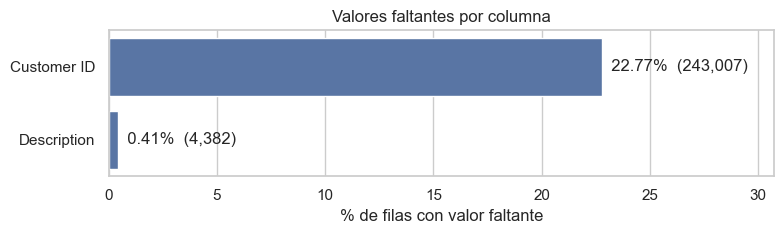

,faltantes,pct_faltantes
Customer ID,243007,22.7669
Description,4382,0.4105
Invoice,0,0.0000
Quantity,0,0.0000
StockCode,0,0.0000
InvoiceDate,0,0.0000
Price,0,0.0000
Country,0,0.0000
Sheet,0,0.0000



3. DUPLICADOS


Filas duplicadas (sin contar la primera aparición): 12,133 (1.14%)
Filas involucradas en algún grupo de duplicados:    23,430


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.9500,"16,329.0000",United Kingdom,Year 2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.9500,"16,329.0000",United Kingdom,Year 2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.7500,"16,329.0000",United Kingdom,Year 2009-2010
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.8500,"16,329.0000",United Kingdom,Year 2009-2010



4. VARIABLES CONTINUAS: ['Quantity', 'Price']


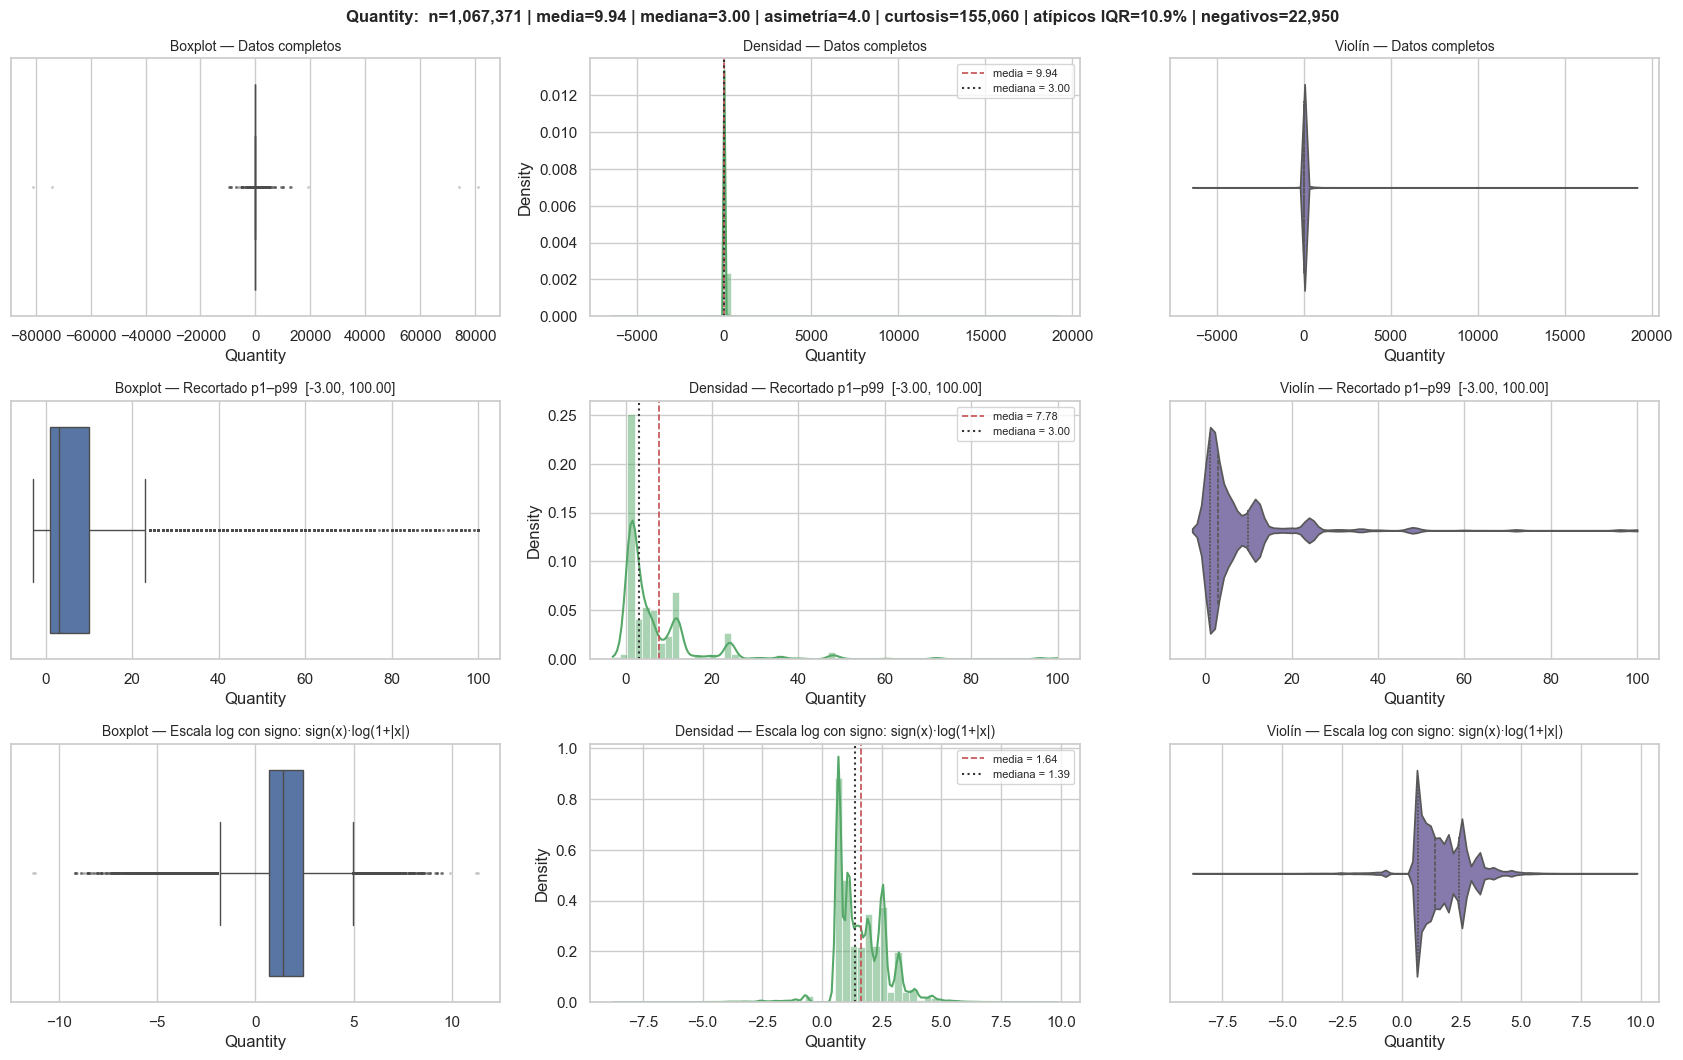

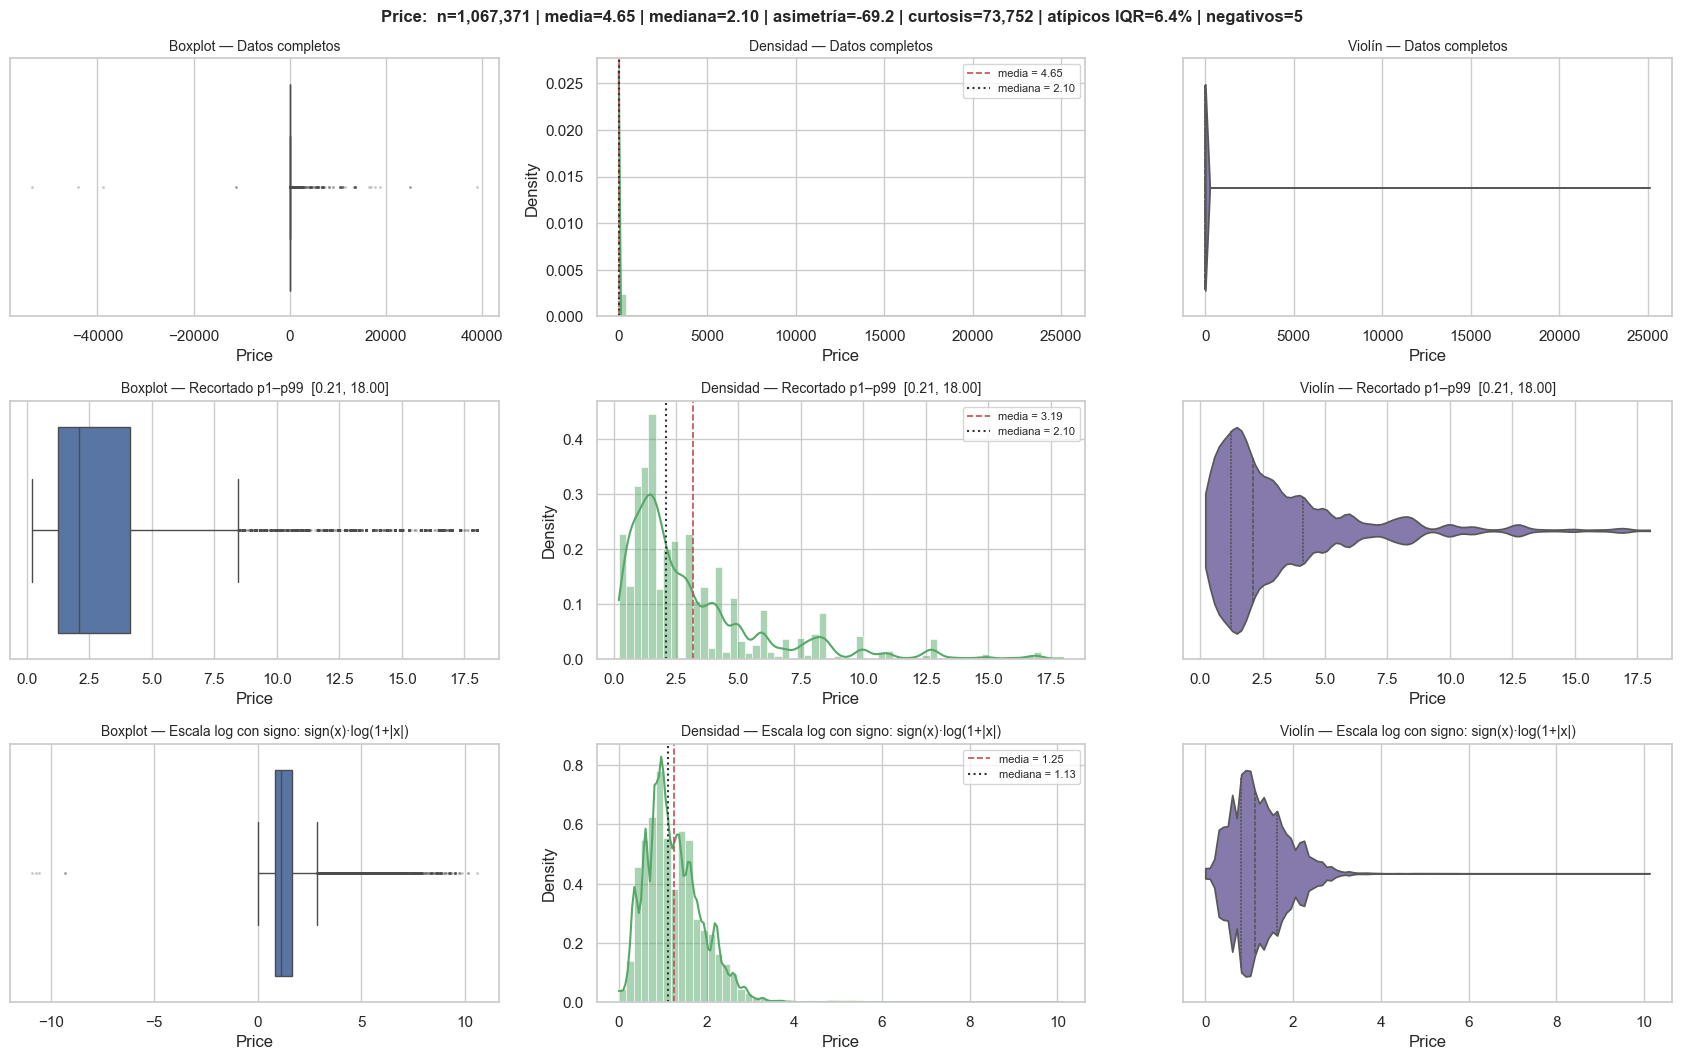

,n,media,mediana,desv_est,min,q1,q3,max,asimetria,curtosis,n_negativos,n_ceros,lim_inf_iqr,lim_sup_iqr,n_atipicos_iqr,pct_atipicos_iqr
Quantity,"1,067,371.0000",9.9389,3.0000,172.7058,"-80,995.0000",1.0000,10.0000,"80,995.0000",3.9961,"155,059.6934","22,950.0000",0.0000,-12.5000,23.5000,"116,489.0000",10.9136
Price,"1,067,371.0000",4.6494,2.1000,123.5531,"-53,594.3600",1.2500,4.1500,"38,970.0000",-69.1647,"73,751.8290",5.0000,"6,202.0000",-3.1000,8.5000,"68,105.0000",6.3806



5. VARIABLES CATEGÓRICAS: ['Country', 'Sheet']


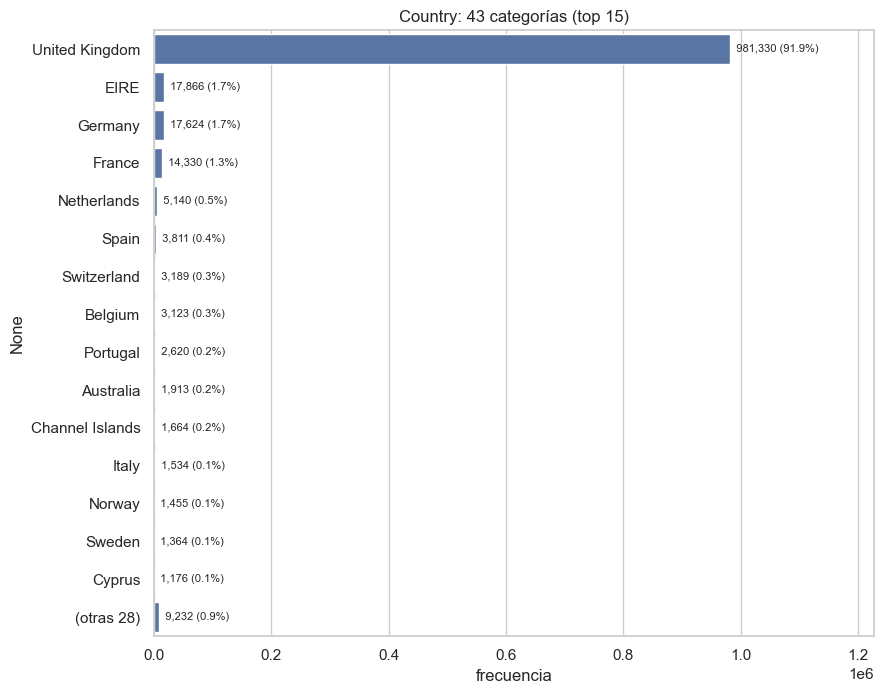

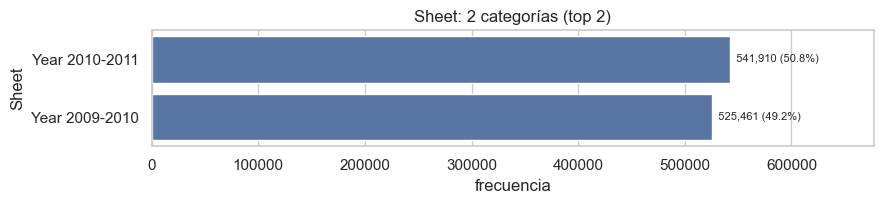


6. VARIABLES DE FECHA: ['InvoiceDate']


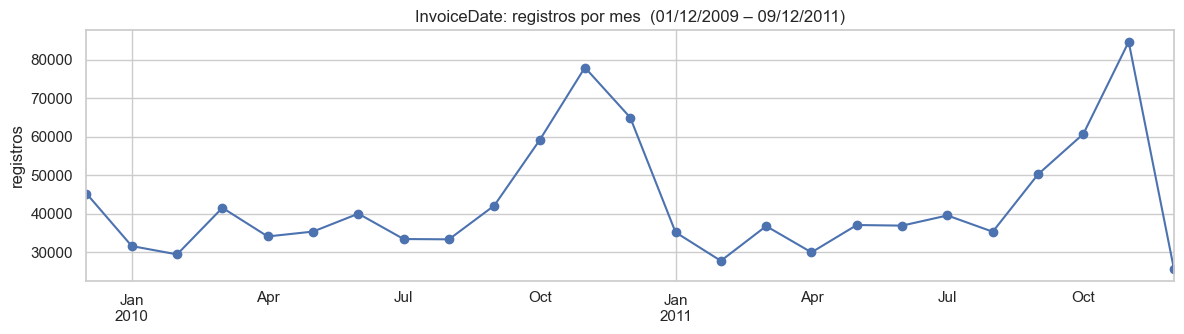

In [6]:
resultado = perfilar(df, ids=["Customer ID"])

**Interpretación del perfilado:**

- **Tipos:** hay 2 **continuas** (`Quantity`, `Price`), 2 **categóricas** (`Country` con 43 países y `Sheet`), 1 **fecha**
  (`InvoiceDate`), 3 **identificadores** (`Invoice` con 53,628 facturas, `StockCode` con 5,305 códigos, `Customer ID` con 5,942 clientes)
  y 1 columna de **texto** (`Description`). Hay 5,698 descripciones para 5,305 códigos, así que algunos códigos tienen más de una descripción.
- **Faltantes:** solo en `Customer ID` (243,007 filas, **22.77%**) y en `Description` (4,382 filas, **0.41%**).
- **Duplicados:** **12,133 filas (1.14%)** son copias exactas dentro de la misma hoja. Son la misma línea de producto repetida en una factura,
  con la misma hora, cantidad y precio. Si además se ignora la columna `Sheet`, suben a 34,335 por el traslape entre hojas (sección 4).
- **`Quantity`:** mediana 3 y media 9.9. Va de −80,995 a 80,995. Esos dos extremos son un pedido gigante y su cancelación inmediata
  (lo mismo pasa con ±74,215). La curtosis es enorme (~155,000). El 10.9% de las filas son atípicas por IQR (> 23.5 unidades): son compras mayoristas.
  Hay 22,950 filas negativas, que corresponden a devoluciones y ajustes.
- **`Price`:** mediana £2.10 y media £4.65. Hay 6,202 precios en cero y 5 negativos, todos ajustes de deuda incobrable (`Adjust bad debt`).
  El máximo es £38,970 y corresponde a conceptos que no son productos (`AMAZONFEE`, `M`, `DOT`). El 6.4% de las filas son atípicas por IQR (> £8.50).
  La asimetría sale **negativa** (−69) solo por el ajuste de −£53,594. Por eso conviene mirar las versiones recortada y logarítmica.
- **`Country`:** Reino Unido tiene el 91.9% de las filas. Le siguen Irlanda (EIRE), Alemania y Francia, con 1.3–1.7% cada uno.
- **`InvoiceDate`:** hay una estacionalidad clara. La actividad sube de septiembre a noviembre y noviembre es el mes pico de cada año
  (76,584 líneas en 2010 y 83,343 en 2011). Dic-2011 sale bajo porque los datos terminan el día 9. Los primeros días de dic-2010 salen inflados
  porque están en las dos hojas.

### 3.2 Identificadores y texto de alta cardinalidad

Estas columnas no se grafican como distribuciones, pero conviene ver su cardinalidad y sus valores más frecuentes.

In [7]:
ids_texto = resultado["tipos"].query("tipo_inferido in ['identificador', 'texto (alta cardinalidad)']").index
for col in ids_texto:
    print(f"\n{col}: {df[col].nunique():,} valores distintos | {df[col].isna().sum():,} faltantes")
    print(df[col].value_counts().head(5).to_string())


Invoice: 53,628 valores distintos | 0 faltantes
Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186

StockCode: 5,305 valores distintos | 0 faltantes
StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259



Description: 5,698 valores distintos | 4,382 faltantes
Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765

Customer ID: 5,942 valores distintos | 243,007 faltantes
Customer ID
17,841.0000    13097
14,911.0000    11613
12,748.0000     7307
14,606.0000     6709
14,096.0000     5128


## 4. Hallazgos específicos del dominio

El perfilado general no capta algunas reglas del negocio. Aquí se revisan:
- **Cancelaciones**: facturas que empiezan con `C`.
- **Otros prefijos de factura** (por ejemplo `A` = *Adjust bad debt*).
- **`Quantity` ≤ 0** y **`Price` ≤ 0**.
- **`StockCode` que no son productos**: envío (`POST`), manual (`M`), comisiones bancarias, etc.
- **Traslape entre las dos hojas** del Excel.

In [8]:
prefijo = df["Invoice"].str.extract(r"^([A-Za-z]*)")[0].replace("", "(sin prefijo)")
print("Prefijos de Invoice:")
print(prefijo.value_counts().to_string())

cancelada = df["Invoice"].str.startswith("C")
print("\nQuantity por tipo de factura:")
display(df.groupby(cancelada.map({True: "cancelada", False: "normal"}))["Quantity"].describe())

print("Facturas con prefijo distinto de C:")
display(df[prefijo.isin(set(prefijo.unique()) - {"(sin prefijo)", "C"})].head(10))

Prefijos de Invoice:
0
(sin prefijo)    1047871
C                  19494
A                      6

Quantity por tipo de factura:


,count,mean,std,min,25%,50%,75%,max
Invoice,,,,,,,,
cancelada,"19,494.0000",-25.1868,805.1049,"-80,995.0000",-6.0000,-2.0000,-1.0000,1.0000
normal,"1,047,877.0000",10.5924,135.2806,"-9,600.0000",1.0000,3.0000,10.0000,"80,995.0000"


Facturas con prefijo distinto de C:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.3600",NaN,United Kingdom,Year 2009-2010
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.7900",NaN,United Kingdom,Year 2009-2010
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.8700",NaN,United Kingdom,Year 2009-2010
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,"11,062.0600",NaN,United Kingdom,Year 2010-2011
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.0600",NaN,United Kingdom,Year 2010-2011
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.0600",NaN,United Kingdom,Year 2010-2011


In [9]:
anomalias = pd.Series({
    "Filas de facturas canceladas (Invoice con 'C')": cancelada.sum(),
    "Quantity < 0": (df["Quantity"] < 0).sum(),
    "Quantity < 0 en facturas NO canceladas": ((df["Quantity"] < 0) & ~cancelada).sum(),
    "Quantity == 0": (df["Quantity"] == 0).sum(),
    "Price < 0": (df["Price"] < 0).sum(),
    "Price == 0": (df["Price"] == 0).sum(),
    "Customer ID faltante": df["Customer ID"].isna().sum(),
    "Description faltante": df["Description"].isna().sum(),
    "Duplicados exactos (todas las columnas)": df.duplicated().sum(),
    "Duplicados exactos ignorando la columna Sheet": df.drop(columns="Sheet").duplicated().sum(),
}).to_frame("filas")
anomalias["pct"] = 100 * anomalias["filas"] / len(df)
display(anomalias)

,filas,pct
Filas de facturas canceladas (Invoice con 'C'),19494,1.8264
Quantity < 0,22950,2.1501
Quantity < 0 en facturas NO canceladas,3457,0.3239
Quantity == 0,0,0.0000
Price < 0,5,0.0005
Price == 0,6202,0.5811
Customer ID faltante,243007,22.7669
Description faltante,4382,0.4105
Duplicados exactos (todas las columnas),12133,1.1367
Duplicados exactos ignorando la columna Sheet,34335,3.2168


**¿Quién tiene `Quantity` negativa sin ser cancelación?** Se revisa si coincide con `Price == 0`, con la falta de cliente
y qué dicen las descripciones (ajustes de inventario, mercancía dañada, etc.).

In [10]:
neg_no_canc = df[(df["Quantity"] < 0) & ~cancelada]
print(f"Price == 0: {(neg_no_canc['Price'] == 0).mean():.1%} | Customer ID faltante: {neg_no_canc['Customer ID'].isna().mean():.1%}")
print("\nDescripciones más frecuentes:")
print(neg_no_canc["Description"].fillna("(faltante)").value_counts().head(15).to_string())

Price == 0: 100.0% | Customer ID faltante: 100.0%

Descripciones más frecuentes:
Description
(faltante)                2689
check                      123
damages                     84
?                           83
damaged                     78
missing                     27
sold as set on dotcom       20
Damaged                     17
smashed                      9
thrown away                  9
Unsaleable, destroyed.       9
dotcom                       8
??                           7
damages?                     7
crushed                      6


**`StockCode` que no siguen el patrón de producto** (5 dígitos, con una letra opcional):

In [11]:
es_producto = df["StockCode"].str.match(r"^\d{5}[A-Za-z]{0,2}$")
no_producto = (df[~es_producto]
               .groupby("StockCode")
               .agg(filas=("Invoice", "size"),
                    descripcion=("Description", lambda s: s.mode().iat[0] if s.notna().any() else None),
                    precio_mediano=("Price", "median"))
               .sort_values("filas", ascending=False))
print(f"Filas con StockCode fuera del patrón: {(~es_producto).sum():,} ({(~es_producto).mean():.2%}) "
      f"| códigos distintos: {len(no_producto)}")
display(no_producto.head(25))

Filas con StockCode fuera del patrón: 6,094 (0.57%) | códigos distintos: 63


,filas,descripcion,precio_mediano
StockCode,,,
POST,2122,POSTAGE,18.0000
DOT,1446,DOTCOM POSTAGE,154.1800
M,1421,Manual,12.6800
C2,282,CARRIAGE,50.0000
D,177,Discount,19.0000
S,104,SAMPLES,29.9950
BANK CHARGES,102,Bank Charges,42.1200
ADJUST,67,Adjustment by john on 26/01/2010 16,49.3500
AMAZONFEE,43,AMAZON FEE,"6,497.4700"


**Los 10 precios más altos del conjunto original** (antes de cualquier limpieza):

In [12]:
top_precio = df.nlargest(10, "Price")
display(top_precio)
print("StockCode de estas filas:", top_precio["StockCode"].value_counts().to_dict())
print(f"¿Alguno sigue el patrón de producto? {top_precio['StockCode'].str.match(r'^\d{5}[A-Za-z]{0,2}$').any()} | "
      f"en facturas canceladas: {top_precio['Invoice'].str.startswith('C').sum()} de {len(top_precio)}")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
748142,C556445,M,Manual,-1,2011-06-10 15:31:00,"38,970.0000","15,098.0000",United Kingdom,Year 2010-2011
241824,C512770,M,Manual,-1,2010-06-17 16:52:00,"25,111.0900","17,399.0000",United Kingdom,Year 2009-2010
241827,512771,M,Manual,1,2010-06-17 16:53:00,"25,111.0900",NaN,United Kingdom,Year 2009-2010
320581,C520667,BANK CHARGES,Bank Charges,-1,2010-08-27 13:42:00,"18,910.6900",NaN,United Kingdom,Year 2009-2010
1050063,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,"17,836.4600",NaN,United Kingdom,Year 2010-2011
569163,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,"16,888.0200",NaN,United Kingdom,Year 2010-2011
569164,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,"16,453.7100",NaN,United Kingdom,Year 2010-2011
517953,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,"13,541.3300",NaN,United Kingdom,Year 2009-2010
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,"13,541.3300",NaN,United Kingdom,Year 2009-2010
519294,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,"13,541.3300",NaN,United Kingdom,Year 2009-2010


StockCode de estas filas: {'AMAZONFEE': 6, 'M': 3, 'BANK CHARGES': 1}
¿Alguno sigue el patrón de producto? False | en facturas canceladas: 8 de 10


**Qué se observa:** ninguno de los 10 precios más altos es un producto. Son ajustes manuales (`M`, hasta £38,970), comisiones
bancarias (`BANK CHARGES`, £18,910) y comisiones de Amazon (`AMAZONFEE`, entre £13,541 y £17,836). Casi todos están en facturas
canceladas (`C…`) con `Quantity` = −1. Por eso el máximo de `Price` baja mucho al quitar los códigos que no son productos (sección 6.5).

**Traslape entre hojas.** Se comparan los rangos de fechas de cada hoja y se cuentan las filas que aparecen en ambas.

In [13]:
display(df.groupby("Sheet")["InvoiceDate"].agg(["min", "max", "size"]))

h1, h2 = df["Sheet"].unique()
cols = [c for c in df.columns if c != "Sheet"]
en_ambas = df[df["Sheet"] == h1][cols].merge(df[df["Sheet"] == h2][cols].drop_duplicates(), how="inner")
print(f"Filas de '{h1}' que también aparecen idénticas en '{h2}': {len(en_ambas):,}")
if len(en_ambas):
    print(f"Rango de fechas del traslape: {en_ambas['InvoiceDate'].min()} – {en_ambas['InvoiceDate'].max()}")

,min,max,size
Sheet,,,
Year 2009-2010,2009-12-01 07:45:00,2010-12-09 20:01:00,525461
Year 2010-2011,2010-12-01 08:26:00,2011-12-09 12:50:00,541910


Filas de 'Year 2009-2010' que también aparecen idénticas en 'Year 2010-2011': 22,523
Rango de fechas del traslape: 2010-12-01 08:26:00 – 2010-12-09 20:01:00


**Distribución de `Price` y `Quantity` solo en ventas válidas** (sin cancelaciones y con `Quantity` > 0 y `Price` > 0), como referencia de cómo quedarían tras limpiar:

Filas de venta válidas: 1,041,670 (97.6%)


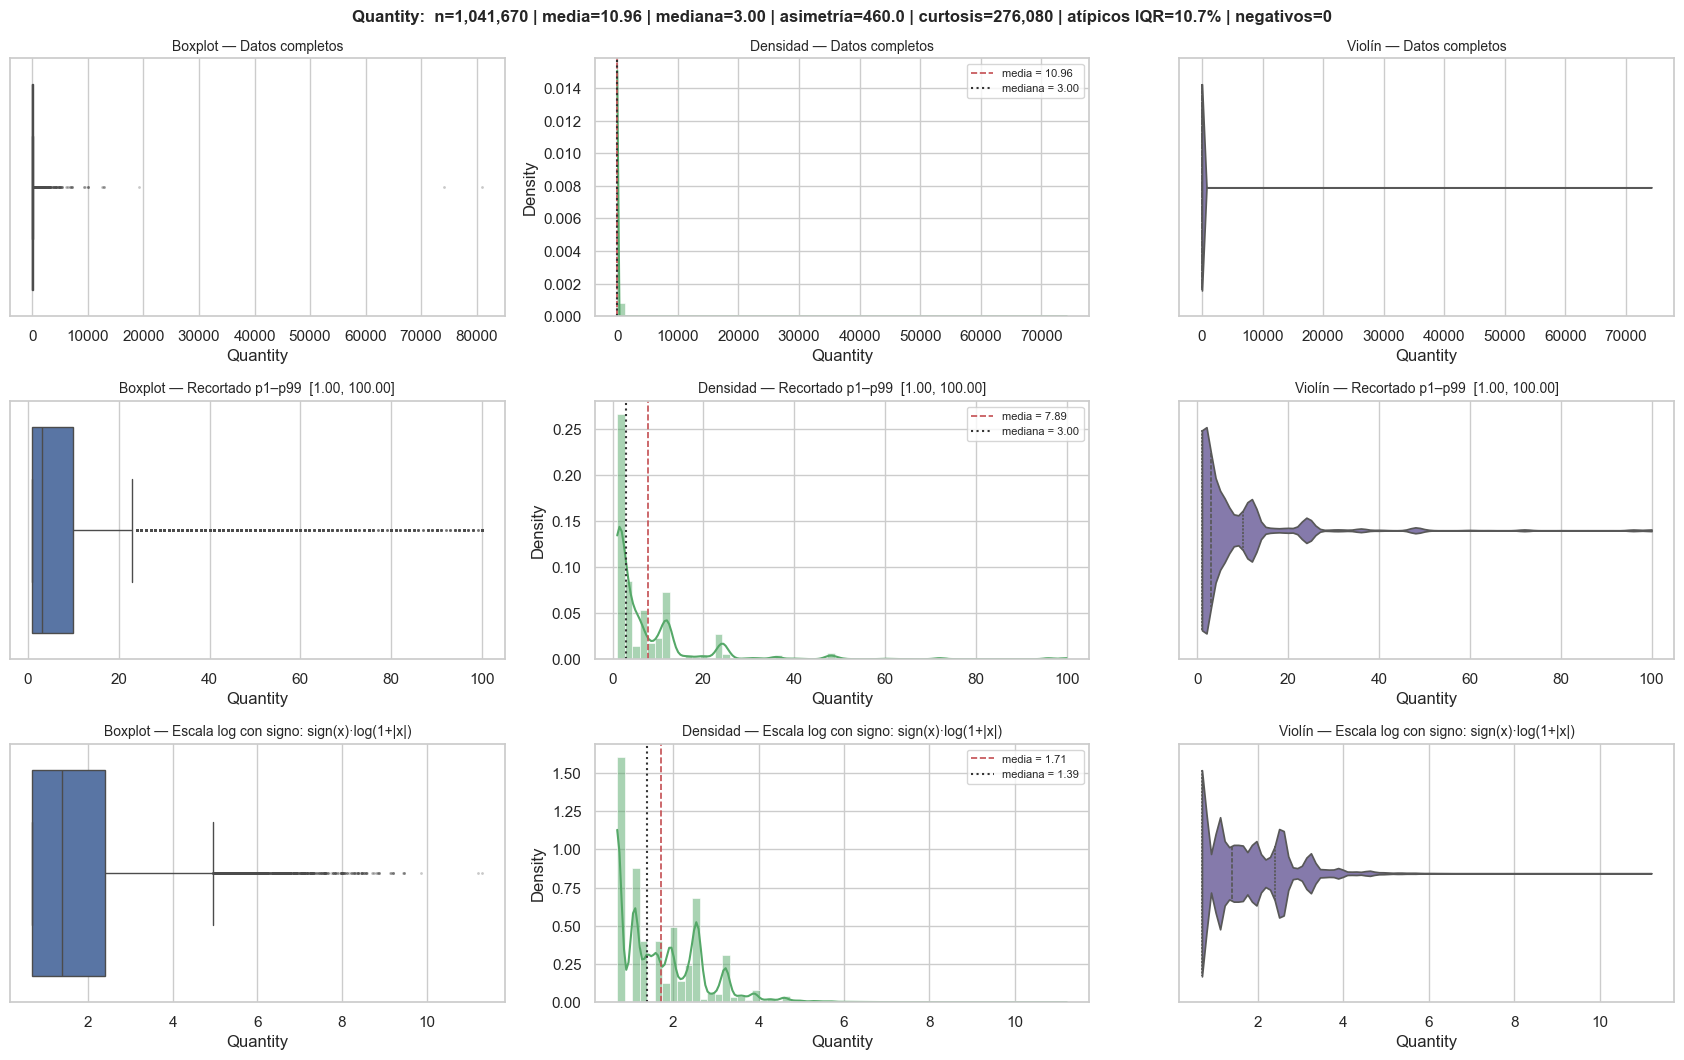

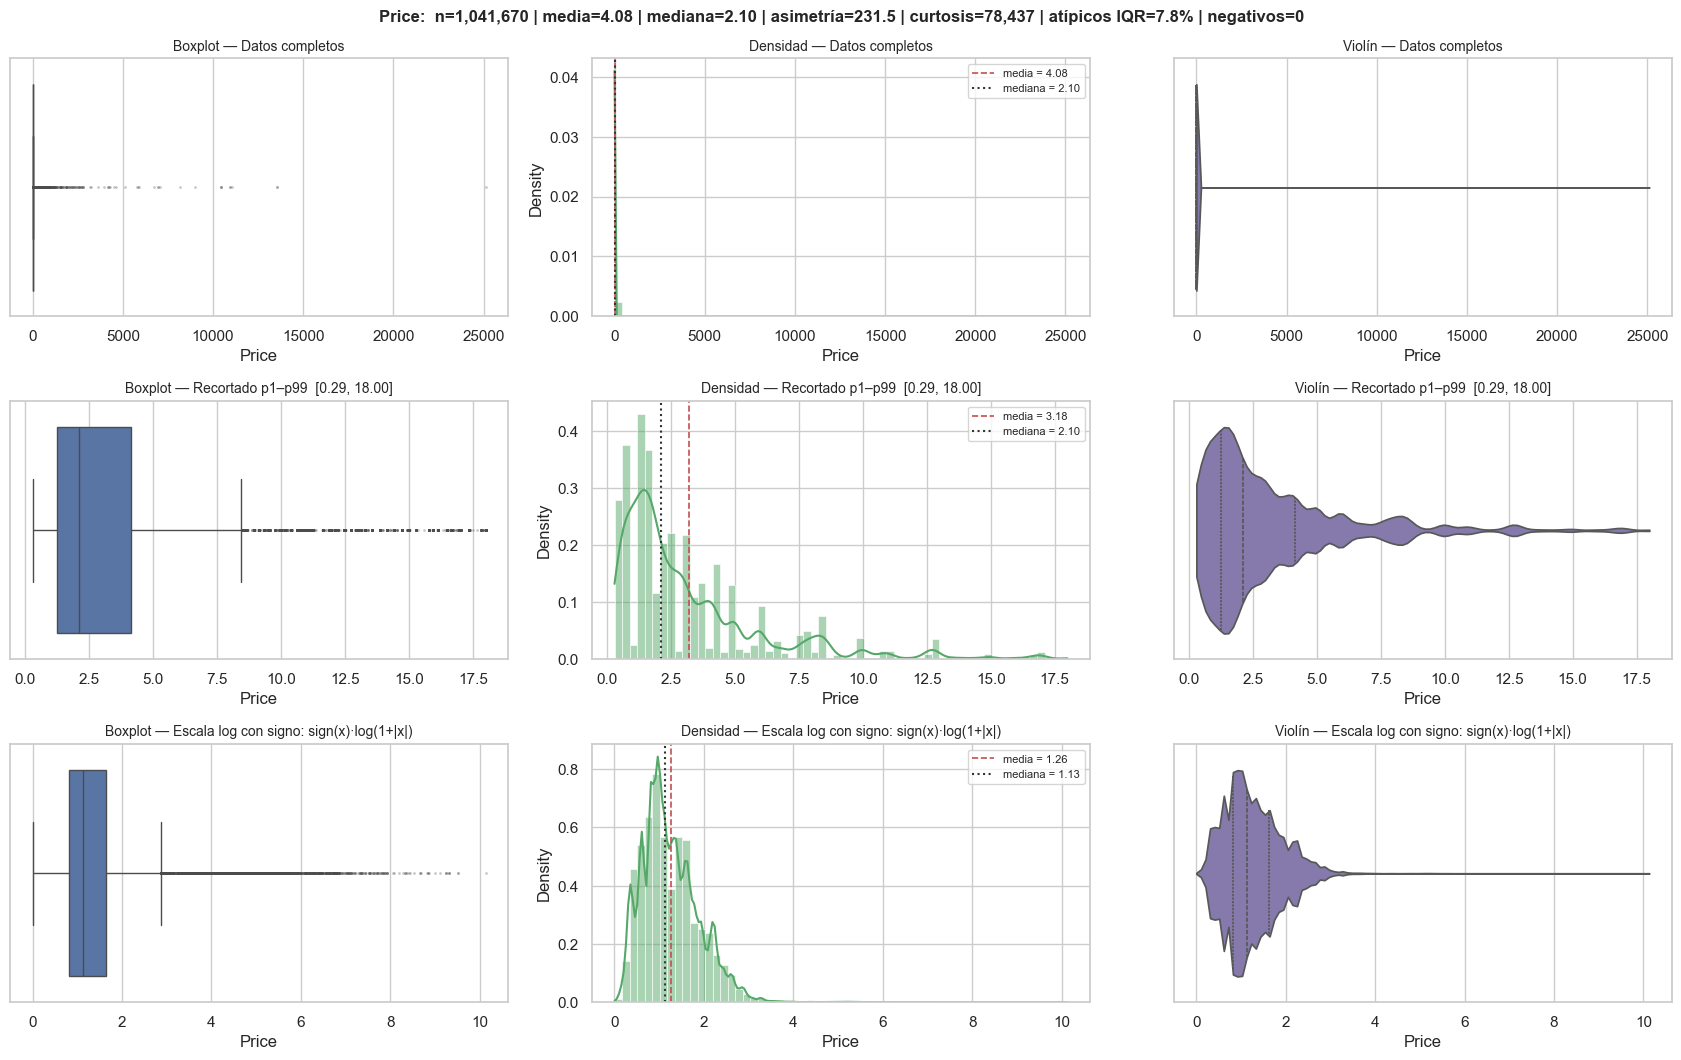

In [14]:
ventas = df[~cancelada & (df["Quantity"] > 0) & (df["Price"] > 0)]
print(f"Filas de venta válidas: {len(ventas):,} ({len(ventas) / len(df):.1%})")
for col in ["Quantity", "Price"]:
    graficar_continua(ventas, col, recorte=(0.01, 0.99), log=True)

## 5. Conclusiones y siguientes pasos de preprocesamiento

### Resumen de calidad

| Problema | Filas | % | Causa |
|---|---:|---:|---|
| Traslape entre hojas (01–09/12/2010) | 22,523 | 2.11% | La segunda hoja empieza el 01/12/2010 y la primera termina el 09/12/2010. |
| `Customer ID` faltante | 243,007 | 22.77% | Compras sin cliente registrado y movimientos internos. |
| Duplicados exactos dentro de una hoja | 12,133 | 1.14% | Líneas repetidas dentro de la misma factura. |
| Facturas canceladas (`C…`) | 19,494 | 1.83% | Devoluciones. Todas tienen `Quantity` ≤ 1 y casi siempre negativa. |
| `Quantity` < 0 sin cancelación | 3,457 | 0.32% | Ajustes de inventario (*damaged*, *missing*, *check*…). Todas tienen `Price` = 0 y no tienen cliente. |
| `Price` = 0 | 6,202 | 0.58% | Ajustes y regalos. |
| `Price` < 0 / facturas `A…` | 5 / 6 | ~0% | Ajustes contables de deuda incobrable (`StockCode` = `B`). |
| `StockCode` que no es producto | 6,094 | 0.57% | Envío (`POST`, `DOT`, `C2`), ajustes manuales (`M`), descuentos (`D`), comisiones (`BANK CHARGES`, `AMAZONFEE`, `CRUK`), muestras, vales y pruebas. |
| `Description` faltante | 4,382 | 0.41% | Coincide sobre todo con los ajustes de inventario. |

### Siguientes pasos de preprocesamiento

> **Estado (sección 6):**
> - **Aplicados:** pasos 1 (duplicados y traslape, sin columna `Sheet`), 3 (ajustes con `Quantity` ≤ 0 y precios negativos),
>   4 (`StockCode` que no son productos) y la conversión de `Customer ID` a `Int64`. Las cancelaciones (paso 2) y las filas con
>   precio 0 se separaron en sus propios conjuntos.
> - **Aplicado en parte:** paso 6. `Description` se normalizó (mayúsculas, sin apóstrofos ni espacios sobrantes), pero **no** se
>   eligió una sola descripción por código: en `ventas` siguen 592 `StockCode` con más de una (sección 7.1). Además, `StockCode` se pasó a mayúsculas (sección 6.10).
> - **Solo revisados:** paso 8 (atípicos).
> - **No aplicados, por decisión:** pasos 7 y 9 (no se crean variables derivadas y `Country` no se modifica).

1. **Quitar el traslape entre hojas:** eliminar duplicados ignorando la columna `Sheet` y luego eliminar `Sheet`. Así también se van los 12,133 duplicados exactos. Quedan ~1,033,036 filas.
2. **Separar las cancelaciones** (`Invoice` que empieza con `C`) en otra tabla. Sirven para analizar devoluciones, pero no son ventas.
3. **Eliminar los ajustes de inventario y contables:** `Quantity` ≤ 0 sin cancelación, `Price` ≤ 0 y facturas `A…`.
4. **Decidir qué hacer con los `StockCode` que no son productos.** Para análisis de canasta o de productos, excluirlos. Para ingresos, conservar envíos y descuentos en una columna aparte.
5. **`Customer ID` faltante:** **no imputar**, porque es un identificador. Para análisis por cliente (RFM, segmentación, CLV), descartar esas filas. Para análisis de ventas o productos, conservarlas con la etiqueta "sin cliente". Convertir la columna a entero o texto (`Int64`/`string`).
6. **`Description`:** normalizar el texto (espacios y mayúsculas) y resolver qué descripción usar cuando un `StockCode` tiene varias (por ejemplo, la más frecuente).
7. **Variables derivadas:** importe de la línea (`Quantity × Price`) y año, mes, día de la semana y hora a partir de `InvoiceDate`. Con eso se puede modelar la estacionalidad de septiembre a noviembre.
8. **Atípicos:** después de limpiar, las colas de `Quantity` y `Price` siguen siendo largas, pero son reales (compras mayoristas). No conviene eliminarlas. Para modelar, usar una transformación logarítmica o recortar al percentil 99 (*winsorizing*).
9. **`Country`:** por el desbalance, considerar agrupar en `United Kingdom` contra el resto, o juntar los países con pocas filas en "Otros".

## 6. Preprocesamiento

Se aplica una primera limpieza sobre una copia `dfl`. El `df` original de las secciones anteriores no se modifica. Pasos:

1. **Eliminar duplicados** ignorando la columna `Sheet` (así también se quita el traslape entre hojas) y luego **eliminar `Sheet`**.
2. **Revisar, sin eliminar**, las cancelaciones, las filas con `Quantity` ≤ 0 y las filas con `Price` ≤ 0.
3. **Eliminar los `StockCode` que no son productos** (envíos, ajustes, comisiones, vales, pruebas).
4. **Revisar `Customer ID`**: comprobar que sus valores son enteros, convertirlo y volver a medir los faltantes.
5. **Revisar códigos con varias descripciones**, todavía sin normalizar `Description`.
6. **Mostrar filas con valores atípicos.**
7. **Eliminar las filas con `Quantity` ≤ 0 que no son cancelaciones** (ajustes de inventario).
8. **Normalizar `StockCode` y `Description`**: `StockCode` en mayúsculas; `Description` en mayúsculas, sin apóstrofos y sin espacios sobrantes.
9. **Separar en tres conjuntos**: `cancelaciones`, `precio_cero` y `ventas`. Después se perfila `ventas` (sección 7).

No se crean variables derivadas y `Country` no se modifica.

### 6.1 Duplicados y columna `Sheet`

In [15]:
dfl = df.copy()
filas_original = len(dfl)

cols_sin_sheet = [c for c in dfl.columns if c != "Sheet"]
dfl = (dfl.drop_duplicates(subset=cols_sin_sheet, keep="first")
          .drop(columns="Sheet")
          .reset_index(drop=True))
filas_sin_dup = len(dfl)

print(f"Filas originales:        {filas_original:,}")
print(f"Filas sin duplicados:    {filas_sin_dup:,}")
print(f"Filas eliminadas:        {filas_original - filas_sin_dup:,} ({(filas_original - filas_sin_dup) / filas_original:.2%})")
print(f"Duplicados restantes:    {dfl.duplicated().sum()}")
print(f"Columnas:                {list(dfl.columns)}")

Filas originales:        1,067,371
Filas sin duplicados:    1,033,036
Filas eliminadas:        34,335 (3.22%)


Duplicados restantes:    0
Columnas:                ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


### 6.2 Facturas canceladas (`Invoice` que empieza con `C`) — solo revisión

Una cancelación registra la devolución de una compra anterior. Lleva la misma línea de producto con `Quantity` negativa.

In [16]:
es_cancelada = dfl["Invoice"].str.startswith("C")
canceladas = dfl[es_cancelada]
print(f"Líneas canceladas: {len(canceladas):,} ({es_cancelada.mean():.2%}) | "
      f"facturas canceladas distintas: {canceladas['Invoice'].nunique():,} | "
      f"clientes distintos: {canceladas['Customer ID'].nunique():,}")

print("\nPrimeras líneas canceladas:")
display(canceladas.head(10))

print("Estadísticas de Quantity y Price en cancelaciones:")
display(canceladas[["Quantity", "Price"]].describe().T)

Líneas canceladas: 19,104 (1.85%) | facturas canceladas distintas: 8,292 | clientes distintos: 2,572

Primeras líneas canceladas:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.9500,"16,321.0000",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.6500,"16,321.0000",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.2500,"16,321.0000",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.1000,"16,321.0000",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.9500,"16,321.0000",Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.2500,"16,321.0000",Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.2500,"16,321.0000",Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.8500,"16,321.0000",Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.9500,"16,321.0000",Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.2500,"17,592.0000",United Kingdom


Estadísticas de Quantity y Price en cancelaciones:


,count,mean,std,min,25%,50%,75%,max
Quantity,"19,104.0000",-24.9591,810.4093,"-80,995.0000",-6.0000,-2.0000,-1.0000,1.0000
Price,"19,104.0000",42.8492,574.8108,0.0100,1.4500,2.9500,6.6500,"38,970.0000"


In [17]:
ej = canceladas["Invoice"].value_counts().loc[lambda s: s.between(3, 8)].index[0]
print(f"Una factura cancelada completa ({ej}):")
display(dfl[dfl["Invoice"] == ej])

print("Compra y su cancelación minutos después (StockCode 23166, cliente 12346):")
display(dfl[(dfl["StockCode"] == "23166") & (dfl["Customer ID"] == 12346)])

print("Cancelaciones con Quantity positiva:")
display(canceladas[canceladas["Quantity"] > 0])

Una factura cancelada completa (C552552):


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
677326,C552552,48129,DOORMAT TOPIARY,-10,2011-05-10 10:51:00,6.7500,"16,525.0000",United Kingdom
677327,C552552,22829,SWEETHEART WIRE WALL TIDY,-8,2011-05-10 10:51:00,8.5000,"16,525.0000",United Kingdom
677328,C552552,22796,PHOTO FRAME 3 CLASSIC HANGING,-12,2011-05-10 10:51:00,8.5000,"16,525.0000",United Kingdom
677329,C552552,22494,EMERGENCY FIRST AID TIN,-24,2011-05-10 10:51:00,1.2500,"16,525.0000",United Kingdom
677330,C552552,22219,LOVEBIRD HANGING DECORATION WHITE,-12,2011-05-10 10:51:00,0.8500,"16,525.0000",United Kingdom
677331,C552552,22169,FAMILY ALBUM WHITE PICTURE FRAME,-8,2011-05-10 10:51:00,7.6500,"16,525.0000",United Kingdom
677332,C552552,22090,PAPER BUNTING RETROSPOT,-40,2011-05-10 10:51:00,2.5500,"16,525.0000",United Kingdom
677333,C552552,21181,PLEASE ONE PERSON METAL SIGN,-48,2011-05-10 10:51:00,1.8500,"16,525.0000",United Kingdom


Compra y su cancelación minutos después (StockCode 23166, cliente 12346):


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
557400,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.0400,"12,346.0000",United Kingdom
557405,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.0400,"12,346.0000",United Kingdom


Cancelaciones con Quantity positiva:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
75972,C496350,M,Manual,1,2010-02-01 08:24:00,373.5700,NaN,United Kingdom


**Qué se observa:** hay 19,104 líneas canceladas en 8,292 facturas, de 2,572 clientes. Casi todas tienen `Quantity` negativa y conservan
el precio unitario de la venta original. Los dos valores más extremos del dataset (±80,995 y ±74,215) son pedidos gigantes que se
cancelaron entre 12 y 16 minutos después de hacerlos. La única cancelación con `Quantity` positiva es un ajuste `Manual` (`M`), que se
elimina en el paso 6.5. Las cancelaciones **se conservan** en `dfl`.

### 6.3 `Quantity` ≤ 0 — solo revisión

In [18]:
q_no_pos = dfl["Quantity"] <= 0
print(f"Filas con Quantity <= 0: {q_no_pos.sum():,} ({q_no_pos.mean():.2%})")
print(f"  - de facturas canceladas: {(q_no_pos & es_cancelada).sum():,}")
print(f"  - de facturas NO canceladas: {(q_no_pos & ~es_cancelada).sum():,}")
print(f"  - con Quantity == 0: {(dfl['Quantity'] == 0).sum():,}")

print("\nEjemplos en facturas canceladas:")
display(dfl[q_no_pos & es_cancelada].sample(8, random_state=42))

q_neg_normal = dfl[q_no_pos & ~es_cancelada]
print("Ejemplos en facturas NO canceladas (ajustes de inventario):")
display(q_neg_normal.sample(10, random_state=42))
print(f"De estas: Price == 0 en {(q_neg_normal['Price'] == 0).mean():.1%} | "
      f"sin Customer ID en {q_neg_normal['Customer ID'].isna().mean():.1%}")

Filas con Quantity <= 0: 22,496 (2.18%)
  - de facturas canceladas: 19,103
  - de facturas NO canceladas: 3,393
  - con Quantity == 0: 0

Ejemplos en facturas canceladas:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
158160,C504641,M,Manual,-1,2010-04-15 14:22:00,773.5000,"17,013.0000",United Kingdom
704376,C555267,84836,ZINC METAL HEART DECORATION,-23,2011-06-01 16:15:00,1.2500,"16,359.0000",United Kingdom
667803,C551587,21843,RED RETROSPOT CAKE STAND,-3,2011-05-03 11:27:00,10.9500,"13,505.0000",Switzerland
579333,C543347,22629,SPACEBOY LUNCH BOX,-1,2011-02-07 12:44:00,1.9500,"12,472.0000",Germany
659425,C550648,22697,GREEN REGENCY TEACUP AND SAUCER,-1,2011-04-19 16:36:00,2.9500,"13,134.0000",United Kingdom
154401,C504207,22464,HANGING METAL HEART LANTERN,-3,2010-04-12 11:26:00,1.6500,"15,755.0000",United Kingdom
560336,C541654,21843,RED RETROSPOT CAKE STAND,-6,2011-01-20 11:53:00,10.9500,"12,540.0000",Spain
117259,C500705,16216,LETTER SHAPE PENCIL SHARPENER,-80,2010-03-09 13:46:00,0.1600,"14,748.0000",United Kingdom


Ejemplos en facturas NO canceladas (ajustes de inventario):


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
79707,496789,16065A,NaN,-2,2010-02-03 16:44:00,0.0000,NaN,United Kingdom
191454,507820,84569A,NaN,-89,2010-05-11 13:07:00,0.0000,NaN,United Kingdom
509358,537426,84968E,check,-35,2010-12-06 15:36:00,0.0000,NaN,United Kingdom
82638,497173,90139,NaN,-6,2010-02-05 17:25:00,0.0000,NaN,United Kingdom
87599,497722,85114C,NaN,-11,2010-02-11 18:11:00,0.0000,NaN,United Kingdom
319954,520898,22143,NaN,-88,2010-09-01 09:22:00,0.0000,NaN,United Kingdom
88252,497854,72785A,NaN,-6,2010-02-12 16:47:00,0.0000,NaN,United Kingdom
111548,500164,17109B,NaN,-205,2010-03-05 09:04:00,0.0000,NaN,United Kingdom
723814,557031,21447,NaN,-65,2011-06-16 13:31:00,0.0000,NaN,United Kingdom
510201,537451,84881,NaN,-11,2010-12-07 09:27:00,0.0000,NaN,United Kingdom


De estas: Price == 0 en 100.0% | sin Customer ID en 100.0%


**Qué se observa:** ninguna fila tiene `Quantity == 0`. De las 22,496 filas negativas, 19,103 son cancelaciones. Las 3,393 restantes
son **ajustes de inventario**: todas tienen `Price` = 0 y ninguna tiene cliente, y su descripción suele estar vacía o decir cosas como
*check*, *damaged* o *missing*. Se eliminan en el paso 6.9.

### 6.4 `Price` ≤ 0 — solo revisión

In [19]:
p_cero = dfl["Price"] == 0
p_neg = dfl["Price"] < 0
print(f"Filas con Price == 0: {p_cero.sum():,} ({p_cero.mean():.2%})")
print(f"Filas con Price < 0:  {p_neg.sum():,}")

print("\nTodas las filas con Price < 0:")
display(dfl[p_neg])

print("Ejemplos con Price == 0:")
display(dfl[p_cero].sample(10, random_state=42))
print(f"De las filas con Price == 0: Quantity < 0 en {(dfl.loc[p_cero, 'Quantity'] < 0).mean():.1%} | "
      f"sin Customer ID en {dfl.loc[p_cero, 'Customer ID'].isna().mean():.1%} | "
      f"Description faltante en {dfl.loc[p_cero, 'Description'].isna().mean():.1%}")

Filas con Price == 0: 6,014 (0.58%)
Filas con Price < 0:  5

Todas las filas con Price < 0:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
177338,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.3600",NaN,United Kingdom
273025,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.7900",NaN,United Kingdom
398731,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.8700",NaN,United Kingdom
794040,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.0600",NaN,United Kingdom
794041,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.0600",NaN,United Kingdom


Ejemplos con Price == 0:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
52713,494257,84925E,NaN,-17,2010-01-12 16:44:00,0.0000,NaN,United Kingdom
723814,557031,21447,NaN,-65,2011-06-16 13:31:00,0.0000,NaN,United Kingdom
408894,528943,21016,NaN,-216,2010-10-25 15:30:00,0.0000,NaN,United Kingdom
877767,570120,22570,NaN,6,2011-10-07 12:49:00,0.0000,NaN,United Kingdom
31962,492001,21724,NaN,-99,2009-12-15 11:22:00,0.0000,NaN,United Kingdom
218533,510893,90003B,NaN,-8,2010-06-04 10:07:00,0.0000,NaN,United Kingdom
580571,543453,21429,NaN,1,2011-02-08 12:15:00,0.0000,NaN,United Kingdom
736823,558340,22626,BLACK KITCHEN SCALES,1,2011-06-28 14:01:00,0.0000,NaN,United Kingdom
429150,530890,21269,NaN,-14,2010-11-04 15:08:00,0.0000,NaN,United Kingdom
414661,529519,79140,gone,-8,2010-10-28 15:32:00,0.0000,NaN,United Kingdom


De las filas con Price == 0: Quantity < 0 en 56.4% | sin Customer ID en 98.8% | Description faltante en 71.1%


**Qué se observa:**
- Los 5 precios negativos son ajustes por deuda incobrable (`StockCode` = `B`, facturas `A…`). Desaparecen en el paso 6.5, al eliminar `B`.
- Las 6,014 filas con `Price` = 0 casi nunca tienen cliente (98.8%) y la mayoría no tiene descripción (71.1%). Son ajustes internos o
  artículos regalados. Las que tienen `Quantity` negativa se eliminan en 6.9. El resto se separa en el conjunto `precio_cero` en 6.11.

### 6.5 Eliminación de `StockCode` que no son productos

In [20]:
CODIGOS_NO_PRODUCTO = ["POST", "DOT", "M", "m", "C2", "C3", "D", "S", "BANK CHARGES", "ADJUST", "ADJUST2",
                       "AMAZONFEE", "CRUK", "TEST001", "TEST002", "B", "GIFT"]
es_no_producto = dfl["StockCode"].isin(CODIGOS_NO_PRODUCTO) | dfl["StockCode"].str.match(r"^gift_0001_")

eliminados = (dfl[es_no_producto]
              .groupby("StockCode")
              .agg(filas=("Invoice", "size"),
                   descripciones=("Description",
                                  lambda s: " | ".join(map(str, s.dropna().unique()[:3])) or "(sin descripción)"),
                   precio_mediano=("Price", "median"))
              .sort_values("filas", ascending=False))
display(eliminados)

dfl = dfl[~es_no_producto].reset_index(drop=True)
filas_sin_noprod = len(dfl)
print(f"Filas eliminadas: {es_no_producto.sum():,} | filas restantes: {filas_sin_noprod:,}")
print(f"¿Queda alguno de los códigos eliminados? "
      f"{(dfl['StockCode'].isin(CODIGOS_NO_PRODUCTO) | dfl['StockCode'].str.match(r'^gift_0001_')).any()}")

fuera_patron = dfl.loc[~dfl["StockCode"].str.match(r"^\d{5}[A-Za-z]{0,2}$"), "StockCode"]
print(f"\nCódigos fuera del patrón de 5 dígitos que se conservan (sí son productos): "
      f"{fuera_patron.nunique()} códigos, {len(fuera_patron)} filas")
print(fuera_patron.value_counts().head(10).to_string())

,filas,descripciones,precio_mediano
StockCode,,,
POST,2086,POSTAGE,18.0000
DOT,1425,DOTCOM POSTAGE,152.8000
M,1387,Manual,12.9400
C2,277,CARRIAGE,50.0000
D,173,Discount,18.4200
S,101,SAMPLES,30.0000
BANK CHARGES,100,Bank Charges | Bank Charges,42.1200
ADJUST,67,Adjustment by john on 26/01/2010 16 | Adjustme...,49.3500
AMAZONFEE,36,AMAZON FEE,"5,942.5700"


Filas eliminadas: 5,801 | filas restantes: 1,027,235


¿Queda alguno de los códigos eliminados? False



Códigos fuera del patrón de 5 dígitos que se conservan (sí son productos): 37 códigos, 180 filas
StockCode
DCGS0058     31
DCGSSGIRL    25
DCGSSBOY     23
PADS         19
DCGS0003     14
DCGS0076     14
DCGS0069      6
DCGS0004      5
DCGS0066N     4
DCGS0072      4


**`StockCode` eliminados y su descripción** (conteos después de quitar duplicados):

| StockCode | Filas | Descripción | Qué es |
|---|---:|---|---|
| `POST` | 2,086 | POSTAGE | Cargo por envío postal |
| `DOT` | 1,425 | DOTCOM POSTAGE | Cargo por envío de pedidos de la web |
| `M` | 1,387 | Manual | Ajuste manual de precio o cantidad |
| `m` | 5 | Manual | Igual que `M`, en minúscula |
| `C2` | 277 | CARRIAGE | Cargo por transporte |
| `C3` | 1 | *(sin descripción)* | Probablemente otro cargo de transporte |
| `D` | 173 | Discount | Descuento |
| `S` | 101 | SAMPLES | Muestras |
| `BANK CHARGES` | 100 | Bank Charges / " Bank Charges" | Comisiones bancarias |
| `ADJUST` | 67 | Adjustment by john on 26/01/2010 16 … / Adjustment by Peter on 24/05/2010 1 … | Ajustes contables |
| `ADJUST2` | 3 | Adjustment by Peter on Jun 25 2010 | Ajustes contables |
| `AMAZONFEE` | 36 | AMAZON FEE | Comisión de Amazon |
| `gift_0001_10` … `gift_0001_90` | 100 | Dotcomgiftshop Gift Voucher £10.00 … £90.00 (en `_20` también aparece "to push order througha s stock was"; `_60` y `_90` no tienen descripción) | Vales de regalo |
| `GIFT` | 1 | *(sin descripción)* | Vale de regalo |
| `CRUK` | 16 | CRUK Commission | Comisión a Cancer Research UK |
| `TEST001` | 15 | This is a test product. | Producto de prueba |
| `TEST002` | 2 | This is a test product. | Producto de prueba |
| `B` | 6 | Adjust bad debt | Ajuste por deuda incobrable (facturas `A…`, precios de hasta −£53,594) |
| **Total** | **5,801** | | |

Se conservan otros códigos que no siguen el patrón de 5 dígitos (`DCGS…`, `PADS`, `SP1002`, `47503J`, `DCGSSBOY`, `DCGSSGIRL`…),
porque sí corresponden a productos (artículos para mascotas, bolsas de fiesta, etc.).

### 6.6 `Customer ID`: tipo y faltantes después de la limpieza

El archivo trae `Customer ID` como `float` porque la columna tiene nulos. Primero se comprueba que todos los valores no nulos
sean enteros. Si lo son, se convierte a `Int64`, el entero de pandas que admite nulos (`<NA>`). El `int64` normal no admite nulos.

In [21]:
c = dfl["Customer ID"].dropna()
es_entero = bool((c == c.round()).all())
print(f"¿Todos los Customer ID no nulos son enteros? {es_entero} | rango: {c.min():.0f} – {c.max():.0f}")

if es_entero:
    dfl["Customer ID"] = dfl["Customer ID"].astype("Int64")
print(f"Tipo de Customer ID: {dfl['Customer ID'].dtype}")
display(dfl[["Invoice", "Customer ID"]].head(3))

¿Todos los Customer ID no nulos son enteros? True | rango: 12346 – 18287
Tipo de Customer ID: Int64


,Invoice,Customer ID
0,489434,13085
1,489434,13085
2,489434,13085


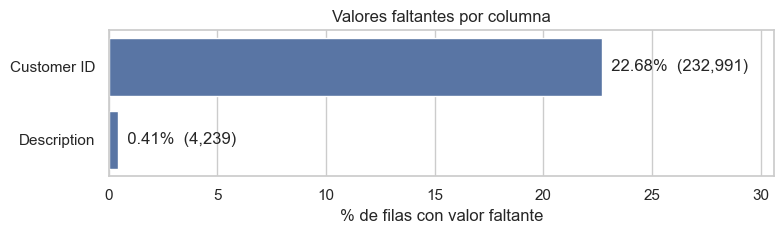

,faltantes,pct_faltantes
Customer ID,232991,22.6814
Description,4239,0.4127
StockCode,0,0.0000
Invoice,0,0.0000
Quantity,0,0.0000
InvoiceDate,0,0.0000
Price,0,0.0000
Country,0,0.0000


Filas sin Customer ID: 232,991 de 1,027,235 (22.68%). En el conjunto original eran 243,007 (22.77%).
Facturas distintas sin cliente: 8,275
De estas filas: canceladas 0.1% | Price == 0 2.5% | Description faltante 1.8%

Países más frecuentes entre las filas sin cliente:
Country
United Kingdom    98.8%
EIRE               0.7%
Hong Kong          0.1%
Unspecified        0.1%
France             0.1%

Ejemplos de filas sin Customer ID:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
165536,505354,21670,BLUE SPOT CERAMIC DRAWER KNOB,1,2010-04-21 15:04:00,2.5100,<NA>,United Kingdom
109528,500028,82585,NaN,5,2010-03-04 11:22:00,0.0000,<NA>,United Kingdom
422128,530422,90214D,"LETTER ""D"" BLING KEY RING",1,2010-11-03 09:36:00,0.8500,<NA>,United Kingdom
707948,555925,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,1,2011-06-07 17:13:00,4.1300,<NA>,United Kingdom
91875,498134,84988,SET OF 72 PINK HEART PAPER DOILIES,1,2010-02-16 17:25:00,2.9800,<NA>,United Kingdom
875312,570258,21218,RED SPOTTY BISCUIT TIN,4,2011-10-10 09:56:00,8.2900,<NA>,United Kingdom
762232,560772,84832,ZINC WILLIE WINKIE CANDLE STICK,2,2011-07-20 16:12:00,1.6300,<NA>,United Kingdom
318650,520992,22616,PACK OF 12 LONDON TISSUES,1,2010-09-01 13:29:00,0.8500,<NA>,United Kingdom
1007469,580367,23173,REGENCY TEAPOT ROSES,1,2011-12-02 16:39:00,19.9600,<NA>,United Kingdom
874677,570236,22139,RETROSPOT TEA SET CERAMIC 11 PC,1,2011-10-09 14:45:00,4.9500,<NA>,United Kingdom


In [22]:
faltantes_post = resumen_faltantes(dfl)
display(faltantes_post)

sin_cliente = dfl[dfl["Customer ID"].isna()]
print(f"Filas sin Customer ID: {len(sin_cliente):,} de {len(dfl):,} ({len(sin_cliente) / len(dfl):.2%}). "
      f"En el conjunto original eran 243,007 (22.77%).")
print(f"Facturas distintas sin cliente: {sin_cliente['Invoice'].nunique():,}")
print(f"De estas filas: canceladas {sin_cliente['Invoice'].str.startswith('C').mean():.1%} | "
      f"Price == 0 {(sin_cliente['Price'] == 0).mean():.1%} | "
      f"Description faltante {sin_cliente['Description'].isna().mean():.1%}")
print("\nPaíses más frecuentes entre las filas sin cliente:")
print(sin_cliente["Country"].value_counts(normalize=True).head(5).map("{:.1%}".format).to_string())

print("\nEjemplos de filas sin Customer ID:")
display(sin_cliente.sample(12, random_state=42))

**Qué se observa:** todos los valores no nulos de `Customer ID` son enteros (12346–18287), así que la columna quedó como `Int64`.
Después de la limpieza, el porcentaje de faltantes casi no cambia: **22.68%** (232,991 filas) contra 22.77% en el conjunto original.
Las filas sin cliente son en su mayoría **ventas normales** a Reino Unido (98.8%), con precio y descripción. Solo el 0.1% son
cancelaciones y el 2.5% tienen precio 0. Parecen compras de clientes no registrados. No conviene imputarlas, porque el identificador
no se puede inferir.

### 6.7 Un mismo `StockCode` con varias descripciones

Aquí `Description` todavía **no se normaliza** (eso se hace en 6.10). Se muestran los textos tal como vienen, y en la columna `repr`
se ven los espacios sobrantes. Las comillas de `repr` solo marcan dónde empieza y termina el texto; no forman parte del dato.

In [23]:
n_desc = dfl.groupby("StockCode")["Description"].nunique().sort_values(ascending=False)
print(f"StockCodes con más de una descripción: {(n_desc > 1).sum():,} de {len(n_desc):,}")
display(n_desc.head(10).to_frame("n_descripciones"))


def descripciones_de(codigo):
    t = (dfl[dfl["StockCode"] == codigo]
         .groupby("Description", dropna=False)
         .agg(filas=("Invoice", "size"), primera=("InvoiceDate", "min"),
              ultima=("InvoiceDate", "max"), precio_mediano=("Price", "median"))
         .sort_values("filas", ascending=False)
         .reset_index())
    t.insert(1, "repr", t["Description"].map(repr))
    return t


codigo = n_desc.index[0]
print(f"\nStockCode {codigo}: {n_desc.iloc[0]} descripciones distintas")
display(descripciones_de(codigo))

StockCodes con más de una descripción: 1,229 de 5,279


,n_descripciones
StockCode,
20713,9
22734,7
22423,7
21181,7
23084,7
85175,6
22719,6
21830,6
47566B,6



StockCode 20713: 9 descripciones distintas


,Description,repr,filas,primera,ultima,precio_mediano
0,JUMBO BAG OWLS,'JUMBO BAG OWLS',1337,2009-12-01 12:13:00,2011-12-09 12:19:00,1.9500
1,NaN,nan,5,2010-08-26 12:26:00,2011-03-29 17:11:00,0.0000
2,Found,'Found',1,2011-10-24 10:53:00,2011-10-24 10:53:00,0.0000
3,Marked as 23343,'Marked as 23343',1,2011-10-26 14:14:00,2011-10-26 14:14:00,0.0000
4,missing,'missing',1,2010-07-05 12:06:00,2010-07-05 12:06:00,0.0000
5,found,'found',1,2011-10-18 11:27:00,2011-10-18 11:27:00,0.0000
6,wrongly coded 23343,'wrongly coded 23343',1,2011-10-27 15:36:00,2011-10-27 15:36:00,0.0000
7,wrongly coded-23343,'wrongly coded-23343',1,2011-10-06 12:38:00,2011-10-06 12:38:00,0.0000
8,wrongly marked 23343,'wrongly marked 23343',1,2011-10-24 17:01:00,2011-10-24 17:01:00,0.0000
9,wrongly marked. 23343 in box,'wrongly marked. 23343 in box',1,2011-07-14 14:27:00,2011-07-14 14:27:00,0.0000


In [24]:
# Códigos cuyas descripciones solo cambian en mayúsculas o espacios. La versión normalizada
# se calcula solo para compararlas; la columna Description no se modifica.
norm = dfl["Description"].str.upper().str.split().str.join(" ")
solo_formato = (dfl.assign(norm=norm).groupby("StockCode")
                .agg(crudas=("Description", "nunique"), normalizadas=("norm", "nunique"))
                .query("crudas > 1 and normalizadas == 1")
                .sort_values("crudas", ascending=False))
print(f"StockCodes cuyas descripciones solo difieren en mayúsculas o espacios: {len(solo_formato):,}")
codigo_fmt = solo_formato.index[0]
print(f"\nEjemplo: StockCode {codigo_fmt}")
display(descripciones_de(codigo_fmt))

distintas = n_desc[(n_desc > 1) & ~n_desc.index.isin(solo_formato.index)].index[1]
print(f"Ejemplo con textos realmente distintos: StockCode {distintas}")
display(descripciones_de(distintas))

StockCodes cuyas descripciones solo difieren en mayúsculas o espacios: 21

Ejemplo: StockCode 16011


,Description,repr,filas,primera,ultima,precio_mediano
0,ANIMAL STICKERS,'ANIMAL STICKERS',101,2010-03-10 12:13:00,2011-12-07 12:41:00,0.2100
1,ANIMAL STICKERS,' ANIMAL STICKERS',12,2009-12-04 11:22:00,2010-03-05 10:14:00,0.2100


Ejemplo con textos realmente distintos: StockCode 22734


,Description,repr,filas,primera,ultima,precio_mediano
0,SET OF 6 RIBBONS VINTAGE CHRISTMAS,'SET OF 6 RIBBONS VINTAGE CHRISTMAS',778,2010-09-16 11:40:00,2011-12-09 10:51:00,2.8900
1,NaN,nan,5,2010-11-16 12:30:00,2011-04-28 15:59:00,0.0000
2,amazon,'amazon',3,2010-12-03 12:08:00,2010-12-10 14:59:00,0.0000
3,FOUND,'FOUND',1,2011-06-27 16:28:00,2011-06-27 16:28:00,0.0000
4,Carton qnty was 216 not 144 as stat,'Carton qnty was 216 not 144 as stat',1,2010-11-05 14:09:00,2010-11-05 14:09:00,0.0000
5,amazon adjustment,'amazon adjustment',1,2010-11-24 09:51:00,2010-11-24 09:51:00,0.0000
6,amazon sales,'amazon sales',1,2010-12-14 15:13:00,2010-12-14 15:13:00,0.0000
7,amendment,'amendment',1,2010-11-26 11:27:00,2010-11-26 11:27:00,0.0000


**Qué se observa:** 1,229 de 5,279 `StockCode` tienen más de una descripción. Hay dos situaciones distintas:
- **Solo cambia el formato** (21 códigos). Por ejemplo, `16011` aparece como `'ANIMAL STICKERS'` y como `' ANIMAL STICKERS'`, con un espacio al inicio.
- **El texto es distinto.** Casi siempre la descripción "real" del producto concentra cientos de filas, y las demás son **notas de inventario**
  con precio 0: *found*, *missing*, *wrongly coded 23343*, *amazon adjustment*. En el código `20713` (JUMBO BAG OWLS), las notas indican
  que algunas unidades se registraron con un código equivocado.

### 6.8 Filas con valores atípicos

Se usan los límites de 1.5·IQR que calcula `estadisticas_continua` sobre los datos ya limpios. Para cada variable se muestran
las 10 filas con valores más altos, las 10 con valores más bajos y una muestra aleatoria de atípicos. La mayoría de los atípicos
están apenas por encima del límite superior.

In [25]:
atipicos = {}
for col in ["Quantity", "Price"]:
    est = estadisticas_continua(dfl[col])
    mascara = (dfl[col] < est["lim_inf_iqr"]) | (dfl[col] > est["lim_sup_iqr"])
    atipicos[col] = dfl[mascara]
    print("=" * 90)
    print(f"{col}: límites IQR [{est['lim_inf_iqr']:,.2f}, {est['lim_sup_iqr']:,.2f}] -> "
          f"{mascara.sum():,} filas atípicas ({mascara.mean():.2%}): "
          f"{(dfl[col] > est['lim_sup_iqr']).sum():,} altas y {(dfl[col] < est['lim_inf_iqr']).sum():,} bajas")
    print("=" * 90)
    print(f"10 valores más altos de {col}:")
    display(dfl.nlargest(10, col))
    print(f"10 valores más bajos de {col}:")
    display(dfl.nsmallest(10, col))
    print(f"Muestra aleatoria de filas atípicas en {col}:")
    display(atipicos[col].sample(10, random_state=42))

Quantity: límites IQR [-12.50, 23.50] -> 114,294 filas atípicas (11.13%): 109,981 altas y 4,313 bajas
10 valores más altos de Quantity:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1025762,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.0800,16446,United Kingdom
554253,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.0400,12346,United Kingdom
89377,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.1000,13902,Denmark
125116,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.1000,13902,Denmark
125118,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.1000,13902,Denmark
125119,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.1000,13902,Denmark
988129,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0000,13256,United Kingdom
125117,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.1000,13902,Denmark
188834,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,2010-05-10 14:55:00,0.0000,<NA>,United Kingdom
132779,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.2500,17940,United Kingdom


10 valores más bajos de Quantity:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1025763,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.0800,16446,United Kingdom
554258,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.0400,12346,United Kingdom
298572,519017,22759,NaN,-9600,2010-08-13 09:14:00,0.0000,<NA>,United Kingdom
715833,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.0000,<NA>,United Kingdom
715834,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.0000,<NA>,United Kingdom
497751,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.0300,15838,United Kingdom
153785,504311,22197,NaN,-9200,2010-04-12 14:39:00,0.0000,<NA>,United Kingdom
715832,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.0000,<NA>,United Kingdom
190977,507913,10120,Zebra invcing error,-9000,2010-05-11 17:16:00,0.0000,<NA>,United Kingdom
421248,530348,16235,?,-9000,2010-11-02 15:48:00,0.0000,<NA>,United Kingdom


Muestra aleatoria de filas atípicas en Quantity:


...

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
188833,507637,84016,FLAG OF ST GEORGE CAR FLAG,1,2010-05-10 14:55:00,"1,157.1500",<NA>,United Kingdom
134117,502451,84016,FLAG OF ST GEORGE CAR FLAG,1,2010-03-24 14:14:00,867.7900,<NA>,United Kingdom
713018,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5000,15098,United Kingdom
713027,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5000,15098,United Kingdom
177837,506571,84016,FLAG OF ST GEORGE CAR FLAG,1,2010-04-30 13:04:00,408.4000,<NA>,United Kingdom
263785,515349,22656,VINTAGE BLUE KITCHEN CABINET,1,2010-07-12 10:43:00,295.0000,15513,United Kingdom
263786,515349,22655,VINTAGE RED KITCHEN CABINET,1,2010-07-12 10:43:00,295.0000,15513,United Kingdom
264025,515403,22655,VINTAGE RED KITCHEN CABINET,1,2010-07-12 11:40:00,295.0000,<NA>,United Kingdom
265783,515602,22656,VINTAGE BLUE KITCHEN CABINET,1,2010-07-13 14:15:00,295.0000,14895,United Kingdom
267429,515811,22656,VINTAGE BLUE KITCHEN CABINET,1,2010-07-15 08:46:00,295.0000,15259,United Kingdom


10 valores más bajos de Price:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
260,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0000,<NA>,United Kingdom
280,489463,71477,short,-240,2009-12-01 10:52:00,0.0000,<NA>,United Kingdom
281,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0000,<NA>,United Kingdom
459,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0000,<NA>,United Kingdom
3055,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0000,<NA>,United Kingdom
3102,489659,21350,NaN,230,2009-12-01 17:39:00,0.0000,<NA>,United Kingdom
3103,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0000,<NA>,United Kingdom
3109,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0000,<NA>,United Kingdom
3664,489781,84292,NaN,17,2009-12-02 11:45:00,0.0000,<NA>,United Kingdom
4210,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0000,<NA>,United Kingdom


Muestra aleatoria de filas atípicas en Price:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
477182,534843,22423,REGENCY CAKESTAND 3 TIER,4,2010-11-24 13:21:00,12.7500,16292,United Kingdom
615048,546896,23126,FELTCRAFT GIRL AMELIE KIT,1,2011-03-17 18:24:00,9.9600,<NA>,United Kingdom
860491,569230,23397,FOOT STOOL HOME SWEET HOME,1,2011-10-02 15:07:00,9.9500,16533,United Kingdom
554111,541424,22365,DOORMAT RESPECTABLE HOUSE,3,2011-01-17 17:57:00,14.1300,<NA>,United Kingdom
103498,499472,22171,3 HOOK PHOTO SHELF ANTIQUE WHITE,1,2010-02-28 12:16:00,8.5000,14507,United Kingdom
593307,544910,22846,BREAD BIN DINER STYLE RED,2,2011-02-24 14:32:00,16.9500,16072,United Kingdom
480572,535274,21361,LOVE LARGE WOOD LETTERS,2,2010-11-25 13:51:00,12.7500,14415,United Kingdom
764656,560928,22767,TRIPLE PHOTO FRAME CORNICE,2,2011-07-22 10:00:00,9.9500,14852,United Kingdom
389896,527409,35240,ENAMEL BLUE RIM OVAL TRAY SET/2,1,2010-10-17 14:54:00,8.4900,17141,United Kingdom
562700,541999,22795,SWEETHEART RECIPE BOOK STAND,1,2011-01-25 10:45:00,13.2900,<NA>,United Kingdom


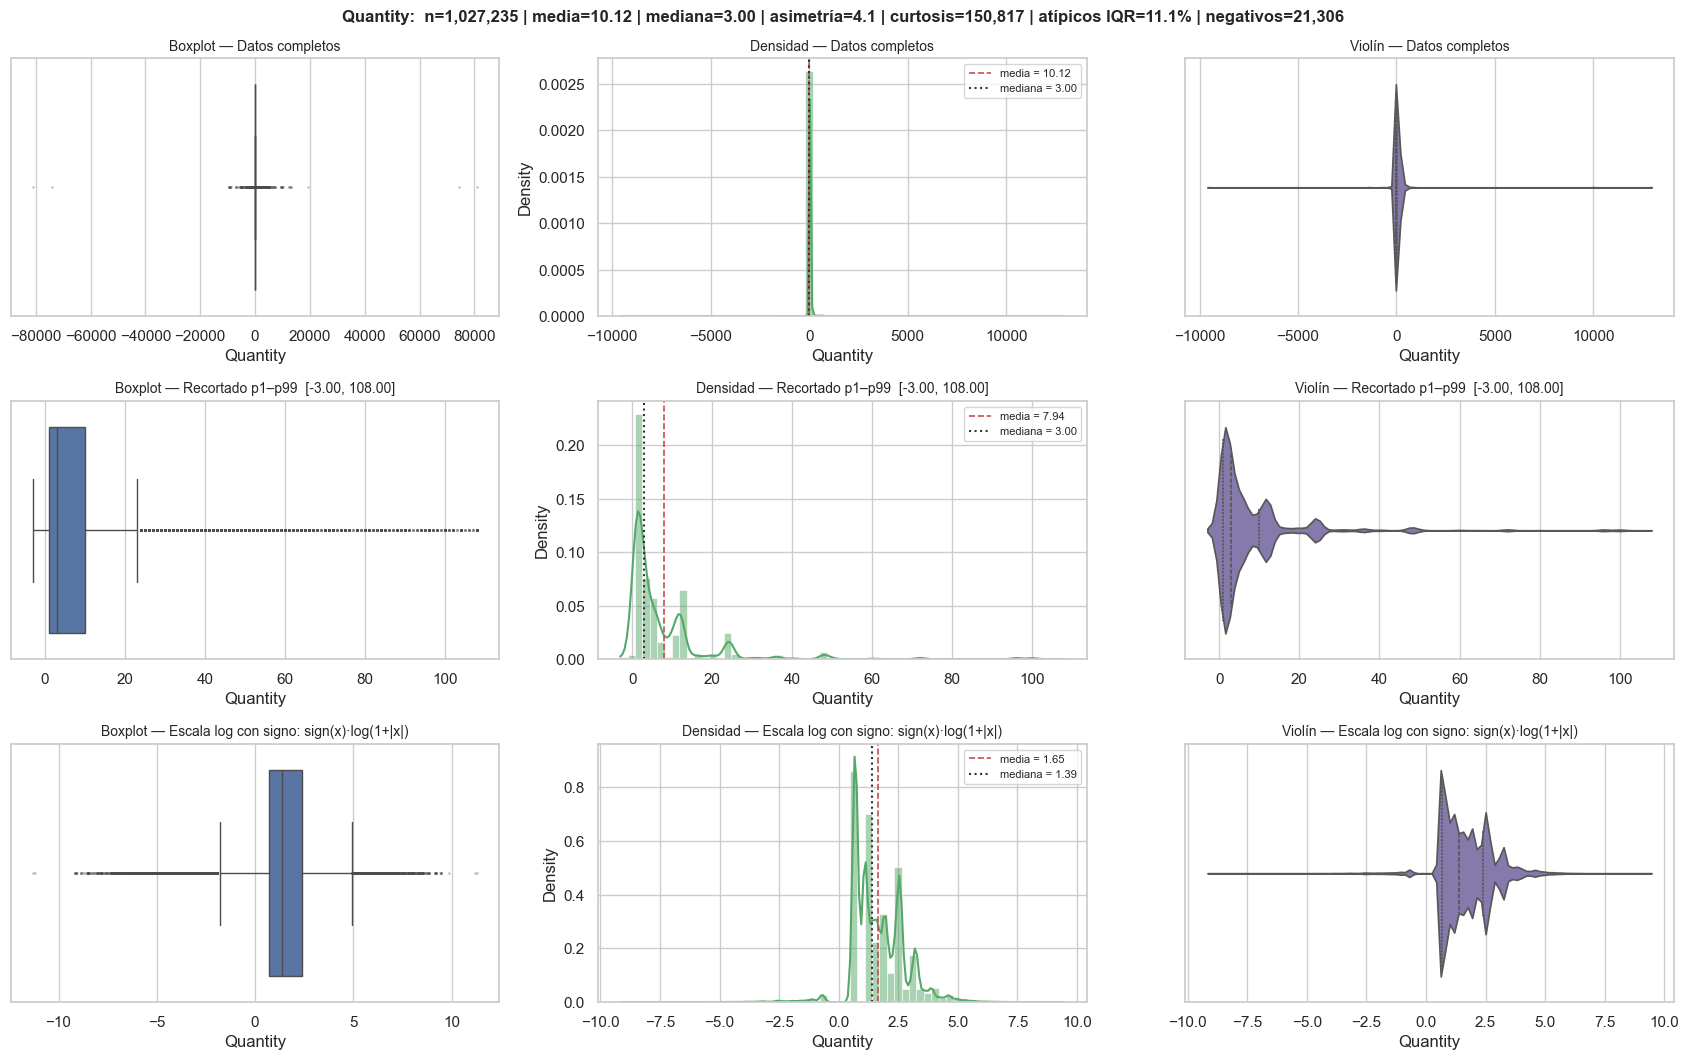

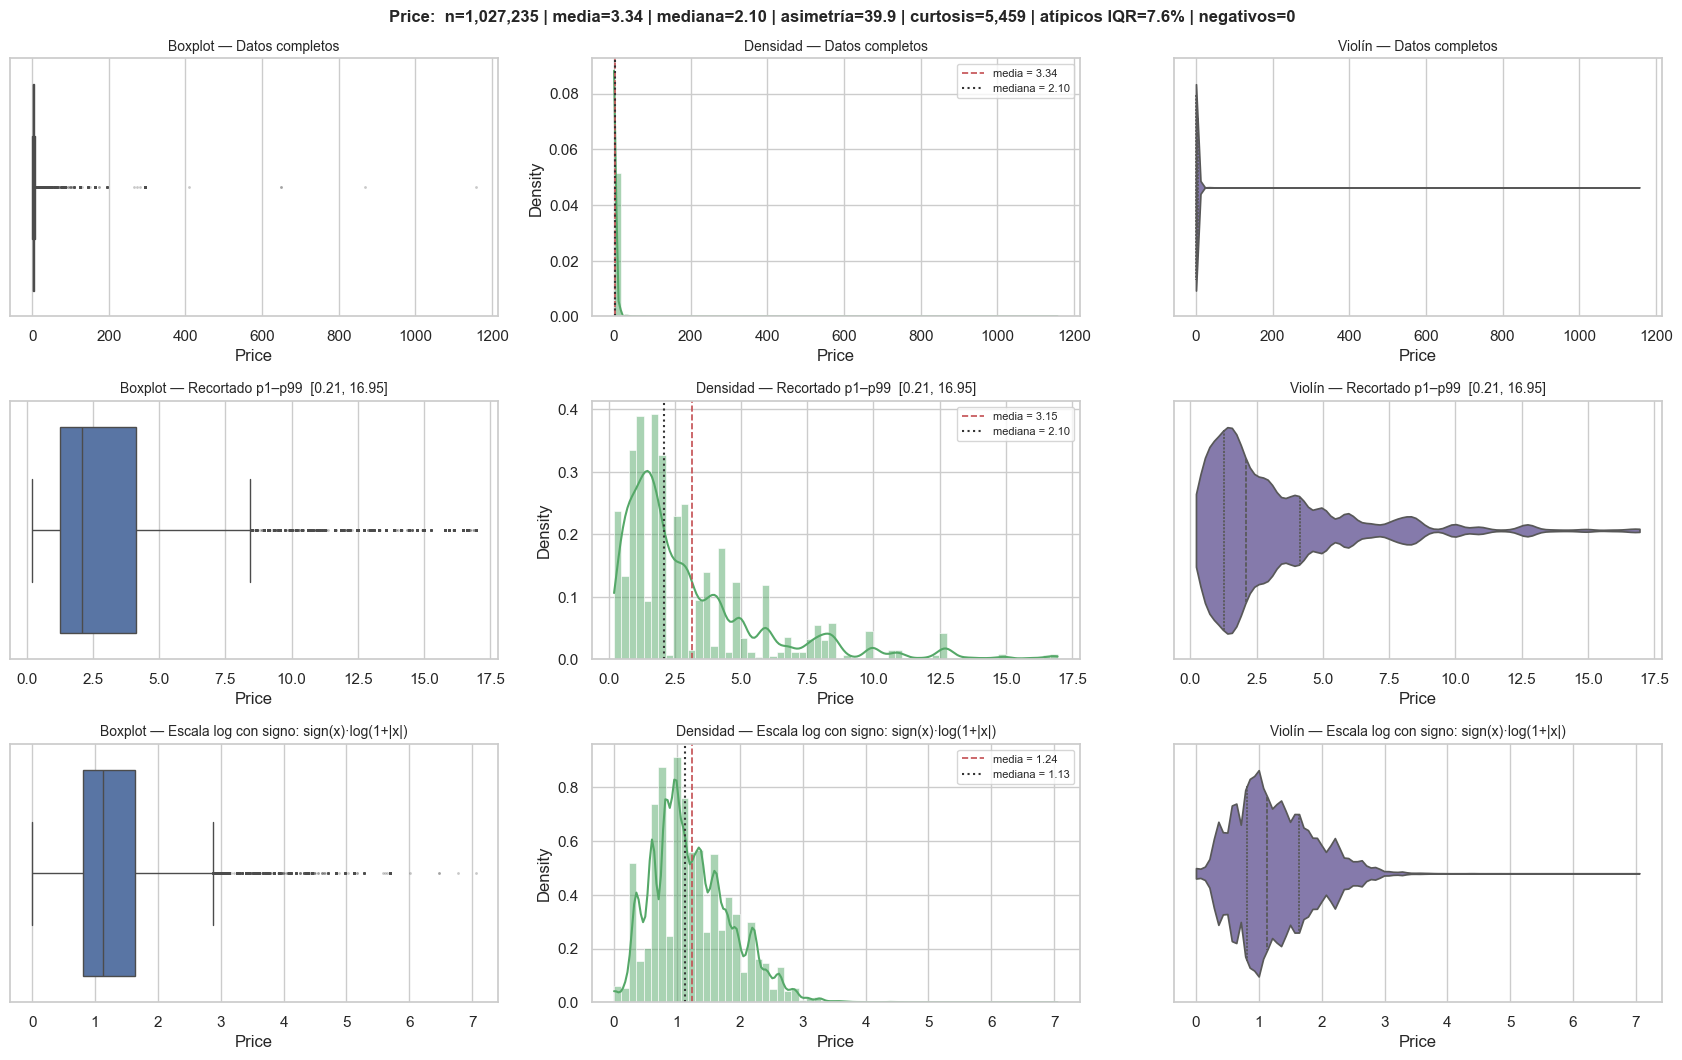

In [26]:
for col in ["Quantity", "Price"]:
    graficar_continua(dfl, col, recorte=(0.01, 0.99), log=True)

**Qué se observa:**
- **`Quantity`:** el 11.1% de las filas son atípicas (fuera de [−12.5, 23.5]). Casi todas son compras mayoristas apenas por encima del
  límite (24, 48, 72, 96 unidades). Las colas extremas son de tres tipos: los dos pedidos gigantes que luego se cancelaron, compras
  reales muy grandes (por ejemplo, el cliente 13902 de Dinamarca con ~12,000–19,000 vasos y platos de papel a £0.10) y ajustes de
  inventario negativos de hasta −9,600 (*printing smudges/thrown away*).
- **`Price`:** el 7.6% de las filas son atípicas, todas por arriba (> £8.45). Tras quitar los cargos que no son productos, el máximo
  baja de £38,970 a £1,157. Ese máximo y otros precios altos corresponden al `StockCode` `84016` (FLAG OF ST GEORGE CAR FLAG), sin
  cliente; parece un error de captura. Los demás valores altos son productos caros reales: muebles de £295 y cestas de picnic de £649.50.

### 6.9 Eliminación de `Quantity` ≤ 0 que no son cancelaciones

Se eliminan los ajustes de inventario revisados en 6.3: filas con `Quantity` ≤ 0 en facturas que **no** empiezan con `C`.
Las cancelaciones se conservan.

In [27]:
es_cancelada = dfl["Invoice"].str.startswith("C")
ajuste_neg = (dfl["Quantity"] <= 0) & ~es_cancelada
print(f"Filas con Quantity <= 0 en facturas no canceladas: {ajuste_neg.sum():,}")

dfl = dfl[~ajuste_neg].reset_index(drop=True)
filas_sin_ajustes = len(dfl)
es_cancelada = dfl["Invoice"].str.startswith("C")
print(f"Filas restantes: {filas_sin_ajustes:,}")
print(f"¿Queda alguna Quantity <= 0 fuera de las cancelaciones? {((dfl['Quantity'] <= 0) & ~es_cancelada).any()}")
print(f"Quantity negativa que queda (solo en cancelaciones): {(dfl['Quantity'] < 0).sum():,}")

Filas con Quantity <= 0 en facturas no canceladas: 3,391


Filas restantes: 1,023,844
¿Queda alguna Quantity <= 0 fuera de las cancelaciones? False
Quantity negativa que queda (solo en cancelaciones): 17,915


### 6.10 Normalización de `StockCode` y `Description`

**`StockCode`.** Algunos códigos aparecen con la letra final en mayúscula y en minúscula (por ejemplo `84997B` y `84997b`) y
comparten descripciones: son el mismo producto escrito de dos formas. Se pasan todos los códigos a **mayúsculas**. Los códigos
con letras distintas (por ejemplo `85099B` y `85099C`, el mismo artículo en otro color) siguen siendo productos distintos.

In [28]:
codigos = pd.Series(dfl["StockCode"].unique())
grupos_caso = codigos.groupby(codigos.str.upper()).agg(list)
grupos_caso = grupos_caso[grupos_caso.str.len() > 1]
con_minuscula = dfl["StockCode"].str.contains(r"[a-z]")
print(f"StockCodes distintos: {dfl['StockCode'].nunique():,} | "
      f"grupos que solo difieren en mayúsculas/minúsculas: {len(grupos_caso):,}")
print(f"Filas con minúsculas en StockCode: {con_minuscula.sum():,} ({con_minuscula.mean():.2%})")
print(f"Ejemplos: {', '.join(' / '.join(g) for g in grupos_caso.head(5))}")

ej = "84997B" if "84997B" in grupos_caso.index else grupos_caso.index[0]
print(f"\nDescripciones del código {ej} en sus dos escrituras:")
display(dfl[dfl["StockCode"].str.upper() == ej].groupby(["StockCode", "Description"]).size().rename("filas").to_frame())

dfl["StockCode"] = dfl["StockCode"].str.upper()
print(f"StockCodes distintos después: {dfl['StockCode'].nunique():,} | "
      f"con minúsculas: {dfl['StockCode'].str.contains(r'[a-z]').sum()} | "
      f"duplicados exactos generados por la unificación: {dfl.duplicated().sum():,}")

StockCodes distintos: 4,973 | grupos que solo difieren en mayúsculas/minúsculas: 170
Filas con minúsculas en StockCode: 3,240 (0.32%)
Ejemplos: 15056BL / 15056bl, 15056N / 15056n, 15056P / 15056p, 15060B / 15060b, 18096C / 18096c

Descripciones del código 84997B en sus dos escrituras:


filas
StockCode Description                             
84997B    CHILDRENS CUTLERY RETROSPOT RED      266
          RED 3 PIECE MINI DOTS CUTLERY SET    502
          RED 3 PIECE RETROSPOT CUTLERY SET    270
84997b    CHILDRENS CUTLERY RETROSPOT RED       58
          RED 3 PIECE MINI DOTS CUTLERY SET      7
          RED 3 PIECE RETROSPOT CUTLERY SET     23

StockCodes distintos después: 4,803 | con minúsculas: 0 | duplicados exactos generados por la unificación: 0


**Qué se observa:** antes de unificar había 4,973 `StockCode` distintos y **170 grupos** de códigos que solo diferían en mayúsculas/minúsculas (`15056BL` / `15056bl`, `15060B` / `15060b`…), en 3,240 filas (0.32%). El ejemplo `84997B` / `84997b` lo confirma: las dos escrituras usan exactamente las mismas tres descripciones. Después de pasar a mayúsculas quedan **4,803** códigos, ninguno con minúsculas, y la unificación **no generó duplicados exactos**.

**`Description`.** Pasos de la normalización:
1. Pasar todo a **mayúsculas**.
2. Quitar los **apóstrofos** (`CHILD'S` → `CHILDS`, `50'S` → `50S`).
3. Quitar los **espacios al inicio y al final**.
4. Dejar **un solo espacio** entre palabras.

Los valores faltantes se quedan como faltantes.

In [29]:
desc_original = dfl["Description"].copy()
dfl["Description"] = (dfl["Description"]
                      .str.upper()
                      .str.replace("'", "", regex=False)
                      .str.strip()
                      .str.replace(r"\s+", " ", regex=True))

cambiadas = desc_original.notna() & (desc_original != dfl["Description"])
print(f"Descripciones distintas: {desc_original.nunique():,} antes -> {dfl['Description'].nunique():,} después")
print(f"Filas cuya descripción cambió: {cambiadas.sum():,} ({cambiadas.mean():.2%})")
print(f"Faltantes: {desc_original.isna().sum():,} antes -> {dfl['Description'].isna().sum():,} después")

antes = desc_original[cambiadas]
ejemplos = pd.concat([antes[antes.str.contains("'", regex=False)].drop_duplicates().head(4),
                      antes[antes.str.contains(r"^\s|\s$|\s\s", regex=True)].drop_duplicates().head(4),
                      antes[antes.str.contains(r"[a-z]", regex=True)].drop_duplicates().head(4)])
print("\nEjemplos (antes -> después). Las comillas solo marcan los extremos del texto:")
display(pd.DataFrame({"antes": ejemplos.map(repr), "despues": dfl.loc[ejemplos.index, "Description"].map(repr)}))

print("Comprobaciones:")
d = dfl["Description"].dropna()
print(f"  con minúsculas: {d.str.contains(r'[a-z]').sum()} | con apóstrofo: {d.str.contains(chr(39)).sum()} | "
      f"con espacios en los extremos o dobles: {d.str.contains(r'^ | $|  ').sum()}")

Descripciones distintas: 5,461 antes -> 5,397 después
Filas cuya descripción cambió: 250,470 (24.46%)
Faltantes: 1,608 antes -> 1,608 después



Ejemplos (antes -> después). Las comillas solo marcan los extremos del texto:


,antes,despues
149,"""PAPER CHAIN KIT 50'S CHRISTMAS """,'PAPER CHAIN KIT 50S CHRISTMAS'
177,"""POTTING SHED SOW 'N' GROW SET""",'POTTING SHED SOW N GROW SET'
294,"""SET OF THREE 50'S GIFT WRAPS """,'SET OF THREE 50S GIFT WRAPS'
332,"""PINK FAIRY CAKE CHILD'S APRON""",'PINK FAIRY CAKE CHILDS APRON'
2,' WHITE CHERRY LIGHTS','WHITE CHERRY LIGHTS'
3,"'RECORD FRAME 7"" SINGLE SIZE '","'RECORD FRAME 7"" SINGLE SIZE'"
5,'PINK DOUGHNUT TRINKET POT ','PINK DOUGHNUT TRINKET POT'
8,'CAT BOWL ','CAT BOWL'
355,'BAG 500g SWIRLY MARBLES','BAG 500G SWIRLY MARBLES'
603,'POLYESTER FILLER PAD 40x40cm','POLYESTER FILLER PAD 40X40CM'


Comprobaciones:


  con minúsculas: 0 | con apóstrofo: 0 | con espacios en los extremos o dobles: 0


In [30]:
n_desc_norm = dfl.groupby("StockCode")["Description"].nunique()
print(f"StockCodes con más de una descripción: {(n_desc > 1).sum():,} antes -> {(n_desc_norm > 1).sum():,} después")
print("\nStockCode 16011 después de normalizar:")
display(descripciones_de("16011"))
print("StockCode 20713 después de normalizar (las notas de inventario ya se eliminaron en 6.9):")
display(descripciones_de("20713"))

StockCodes con más de una descripción: 1,229 antes -> 723 después

StockCode 16011 después de normalizar:


,Description,repr,filas,primera,ultima,precio_mediano
0,ANIMAL STICKERS,'ANIMAL STICKERS',113,2009-12-04 11:22:00,2011-12-07 12:41:00,0.2100


StockCode 20713 después de normalizar (las notas de inventario ya se eliminaron en 6.9):


,Description,repr,filas,primera,ultima,precio_mediano
0,JUMBO BAG OWLS,'JUMBO BAG OWLS',1337,2009-12-01 12:13:00,2011-12-09 12:19:00,1.9500
1,NaN,nan,4,2010-08-26 12:26:00,2011-03-29 17:11:00,0.0000
2,FOUND,'FOUND',2,2011-10-18 11:27:00,2011-10-24 10:53:00,0.0000
3,MARKED AS 23343,'MARKED AS 23343',1,2011-10-26 14:14:00,2011-10-26 14:14:00,0.0000
4,WRONGLY CODED 23343,'WRONGLY CODED 23343',1,2011-10-27 15:36:00,2011-10-27 15:36:00,0.0000
5,WRONGLY MARKED 23343,'WRONGLY MARKED 23343',1,2011-10-24 17:01:00,2011-10-24 17:01:00,0.0000


**Qué se observa:** la normalización cambió el 24.5% de las filas, casi siempre por espacios al final. Las descripciones distintas
bajaron de 5,461 a 5,397, y los `StockCode` con más de una descripción bajaron de 1,229 a 723 (este conteo ya incluye la unificación de `StockCode`). Una parte de los que quedan son filas
con precio 0 que traen notas de inventario (*FOUND*, *WRONGLY CODED 23343*); esas filas pasan al conjunto `precio_cero` en el
siguiente paso. Aun así, en `ventas` siguen **592** códigos con varias descripciones, casi todos porque el producto cambió de nombre
o tiene erratas. Se revisan en la sección 7.1.

### 6.11 Separación en tres conjuntos

| Conjunto | Regla | Uso |
|---|---|---|
| `cancelaciones` | `Invoice` empieza con `C` | Análisis de devoluciones |
| `precio_cero` | No es cancelación y `Price` = 0 | Regalos y ajustes sin valor monetario |
| `ventas` | Todo lo demás | Ventas reales, con `Quantity` > 0 y `Price` > 0 |

In [31]:
es_cancelada = dfl["Invoice"].str.startswith("C")
es_precio_cero = ~es_cancelada & (dfl["Price"] == 0)

cancelaciones = dfl[es_cancelada].reset_index(drop=True)
precio_cero = dfl[es_precio_cero].reset_index(drop=True)
ventas = dfl[~es_cancelada & ~es_precio_cero].reset_index(drop=True)

conjuntos = pd.DataFrame({"filas": [len(cancelaciones), len(precio_cero), len(ventas)]},
                         index=["cancelaciones", "precio_cero", "ventas"])
conjuntos["pct"] = 100 * conjuntos["filas"] / len(dfl)
conjuntos["facturas"] = [x["Invoice"].nunique() for x in (cancelaciones, precio_cero, ventas)]
conjuntos["sin_customer_id_pct"] = [100 * x["Customer ID"].isna().mean() for x in (cancelaciones, precio_cero, ventas)]
display(conjuntos)

print(f"Suma de los tres: {conjuntos['filas'].sum():,} | total dfl: {len(dfl):,} | "
      f"¿coinciden? {conjuntos['filas'].sum() == len(dfl)}")
print(f"Cancelaciones con Price == 0: {(cancelaciones['Price'] == 0).sum()}")
print(f"Ventas -> Quantity <= 0: {(ventas['Quantity'] <= 0).sum()} | Price <= 0: {(ventas['Price'] <= 0).sum()} | "
      f"facturas 'C': {ventas['Invoice'].str.startswith('C').sum()}")

,filas,pct,facturas,sin_customer_id_pct
cancelaciones,17915,1.7498,7406,1.8309
precio_cero,2572,0.2512,1939,97.6283
ventas,1003357,97.9990,39516,22.6002


Suma de los tres: 1,023,844 | total dfl: 1,023,844 | ¿coinciden? True
Cancelaciones con Price == 0: 0
Ventas -> Quantity <= 0: 0 | Price <= 0: 0 | facturas 'C': 0


In [32]:
for nombre, x in [("cancelaciones", cancelaciones), ("precio_cero", precio_cero), ("ventas", ventas)]:
    print(f"{nombre}:")
    display(x.sample(5, random_state=42))

cancelaciones:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3449,C506477,22138,BAKING SET 9 PIECE RETROSPOT,-6,2010-04-30 10:25:00,4.9500,16652,United Kingdom
10476,C542366,72802A,ROSE SCENT CANDLE IN JEWELLED BOX,-1,2011-01-27 12:54:00,3.8100,13777,United Kingdom
13695,C559952,21258,VICTORIAN SEWING BOX LARGE,-2,2011-07-14 10:57:00,6.9500,17696,United Kingdom
4288,C509624,22635,CHILDS BREAKFAST SET DOLLY GIRL,-4,2010-05-25 09:53:00,9.9500,16303,United Kingdom
6526,C521233,22423,REGENCY CAKESTAND 3 TIER,-1,2010-09-03 11:17:00,10.9500,13093,United Kingdom


precio_cero:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1127,524572,84924D,EUROBARGAIN INVC/CREDIT,372,2010-09-29 15:34:00,0.0000,<NA>,United Kingdom
2119,558344,47013C,NaN,4,2011-06-28 14:44:00,0.0000,<NA>,United Kingdom
2337,569463,23268,LIGHTHOUSE TRADING ZERO INVC INCORR,192,2011-10-04 11:39:00,0.0000,<NA>,United Kingdom
367,500027,72045D,NaN,15,2010-03-04 11:20:00,0.0000,<NA>,United Kingdom
1780,546933,22375,AIRLINE BAG VINTAGE JET SET BROWN,1,2011-03-18 11:02:00,0.0000,<NA>,United Kingdom


ventas:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
896272,573585,23334,IVORY WICKER HEART SMALL,6,2011-10-31 14:41:00,1.2500,<NA>,United Kingdom
967493,578996,23469,CARD HOLDER LOVE BIRD SMALL,4,2011-11-27 16:02:00,4.1500,13991,United Kingdom
661844,553013,22678,FRENCH BLUE METAL DOOR SIGN 3,1,2011-05-12 18:19:00,2.4600,<NA>,United Kingdom
103199,499769,84908A,PINK 5 PATCH FLOWER CUSHION COVER,24,2010-03-02 13:25:00,1.9500,13694,United Kingdom
556811,542906,85116,BLACK CANDELABRA T-LIGHT HOLDER,11,2011-02-01 15:12:00,1.6300,<NA>,United Kingdom


**Qué se observa:** las tres partes no se traslapan y suman exactamente `dfl`. Ninguna cancelación tiene precio 0, así que no hay
filas que pudieran ir en dos conjuntos. `precio_cero` es pequeño (2,572 filas) y casi no tiene cliente asignado. `ventas` concentra
el ~98% de las filas y ya solo tiene cantidades y precios positivos.

### 6.12 Resumen y guardado

In [33]:
pasos = pd.DataFrame({"filas": [filas_original, filas_sin_dup, filas_sin_noprod, filas_sin_ajustes]},
                     index=["Original (2 hojas)", "Sin duplicados ni traslape", "Sin StockCodes que no son productos",
                            "Sin Quantity <= 0 fuera de cancelaciones"])
pasos["eliminadas"] = (-pasos["filas"].diff()).fillna(0).astype(int)
pasos["pct_del_original"] = 100 * pasos["filas"] / filas_original
display(pasos)

dfl.info(memory_usage="deep")
archivos = {"retail_ventas.parquet": ventas, "retail_cancelaciones.parquet": cancelaciones,
            "retail_precio_cero.parquet": precio_cero}
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
for ruta, x in archivos.items():
    x.to_parquet(RUTA_PROCESADOS / ruta, index=False)
    print(f"Guardado data/processed/{ruta}: {len(x):,} filas")

,filas,eliminadas,pct_del_original
Original (2 hojas),1067371,0,100.0000
Sin duplicados ni traslape,1033036,34335,96.7832
Sin StockCodes que no son productos,1027235,5801,96.2397
Sin Quantity <= 0 fuera de cancelaciones,1023844,3391,95.9220


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023844 entries, 0 to 1023843
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1023844 non-null  object        
 1   StockCode    1023844 non-null  object        
 2   Description  1022236 non-null  object        
 3   Quantity     1023844 non-null  int64         
 4   InvoiceDate  1023844 non-null  datetime64[ns]
 5   Price        1023844 non-null  float64       
 6   Customer ID  794244 non-null   Int64         
 7   Country      1023844 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 273.4 MB


Guardado data/processed/retail_ventas.parquet: 1,003,357 filas
Guardado data/processed/retail_cancelaciones.parquet: 17,915 filas
Guardado data/processed/retail_precio_cero.parquet: 2,572 filas


## 7. Perfilado de las ventas

Se vuelve a aplicar `perfilar()` sobre el conjunto `ventas`, que ya no tiene cancelaciones, filas con precio 0, ajustes de
inventario, códigos que no son productos ni duplicados.


DIMENSIONES: 1,003,357 filas x 8 columnas  |  memoria: 281.0 MB

1. TIPOS DE VARIABLES INFERIDOS


,dtype,tipo_inferido,n_unicos,pct_unicos,ejemplos
variable,,,,,
Invoice,object,identificador,39516,3.9384,"489434, 489435, 489436"
StockCode,object,identificador,4726,0.4710,"85048, 79323P, 79323W"
Description,object,texto (alta cardinalidad),5322,0.5304,"15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK CHER..."
Quantity,int64,continua,520,0.0518,"12, 48, 24"
InvoiceDate,datetime64[ns],fecha,36736,3.6613,"2009-12-01 07:45:00, 2009-12-01 07:46:00, 2009..."
Price,float64,continua,685,0.0683,"6.95, 6.75, 2.1"
Customer ID,Int64,identificador,5852,0.5832,"13085, 13078, 15362"
Country,object,categórica,43,0.0043,"United Kingdom, France, Australia"



2. VALORES FALTANTES


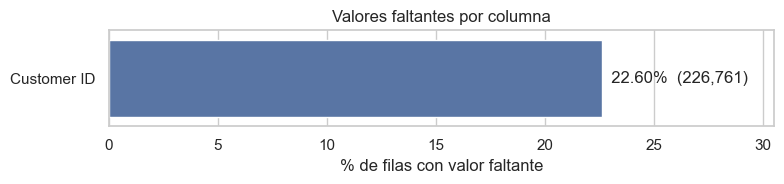

,faltantes,pct_faltantes
Customer ID,226761,22.6002
Invoice,0,0.0000
Description,0,0.0000
StockCode,0,0.0000
Quantity,0,0.0000
InvoiceDate,0,0.0000
Price,0,0.0000
Country,0,0.0000



3. DUPLICADOS


Filas duplicadas (sin contar la primera aparición): 0 (0.00%)
Filas involucradas en algún grupo de duplicados:    0

4. VARIABLES CONTINUAS: ['Quantity', 'Price']


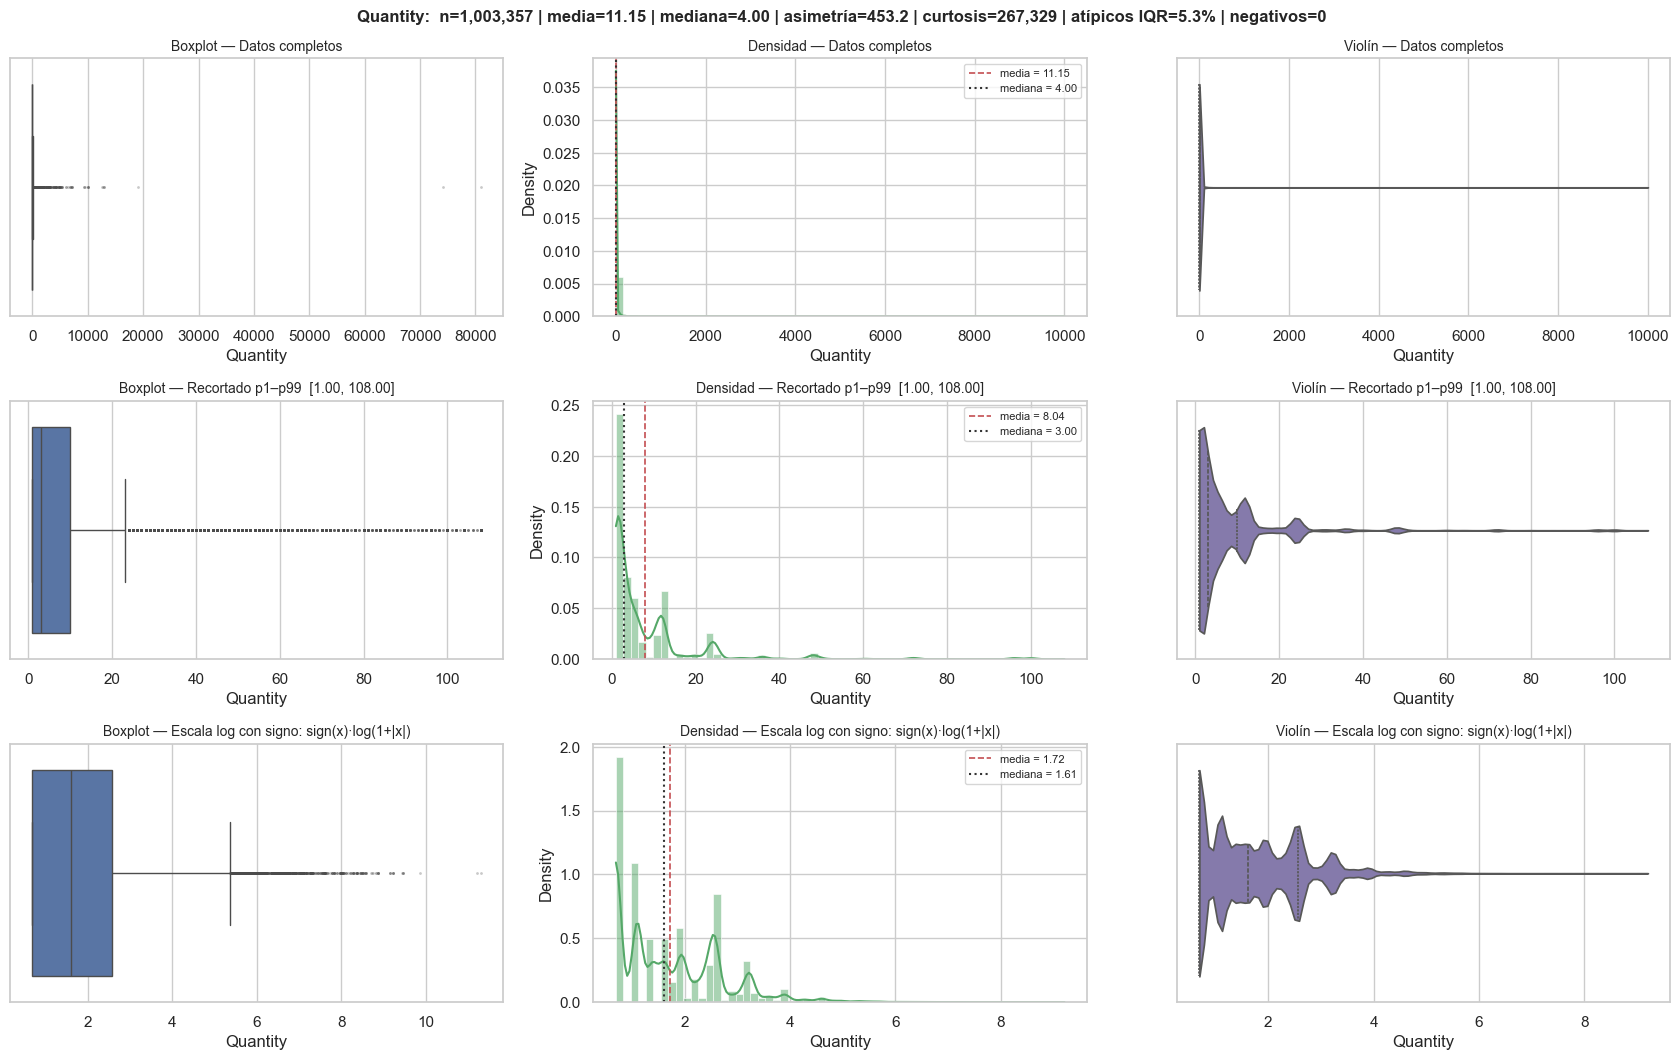

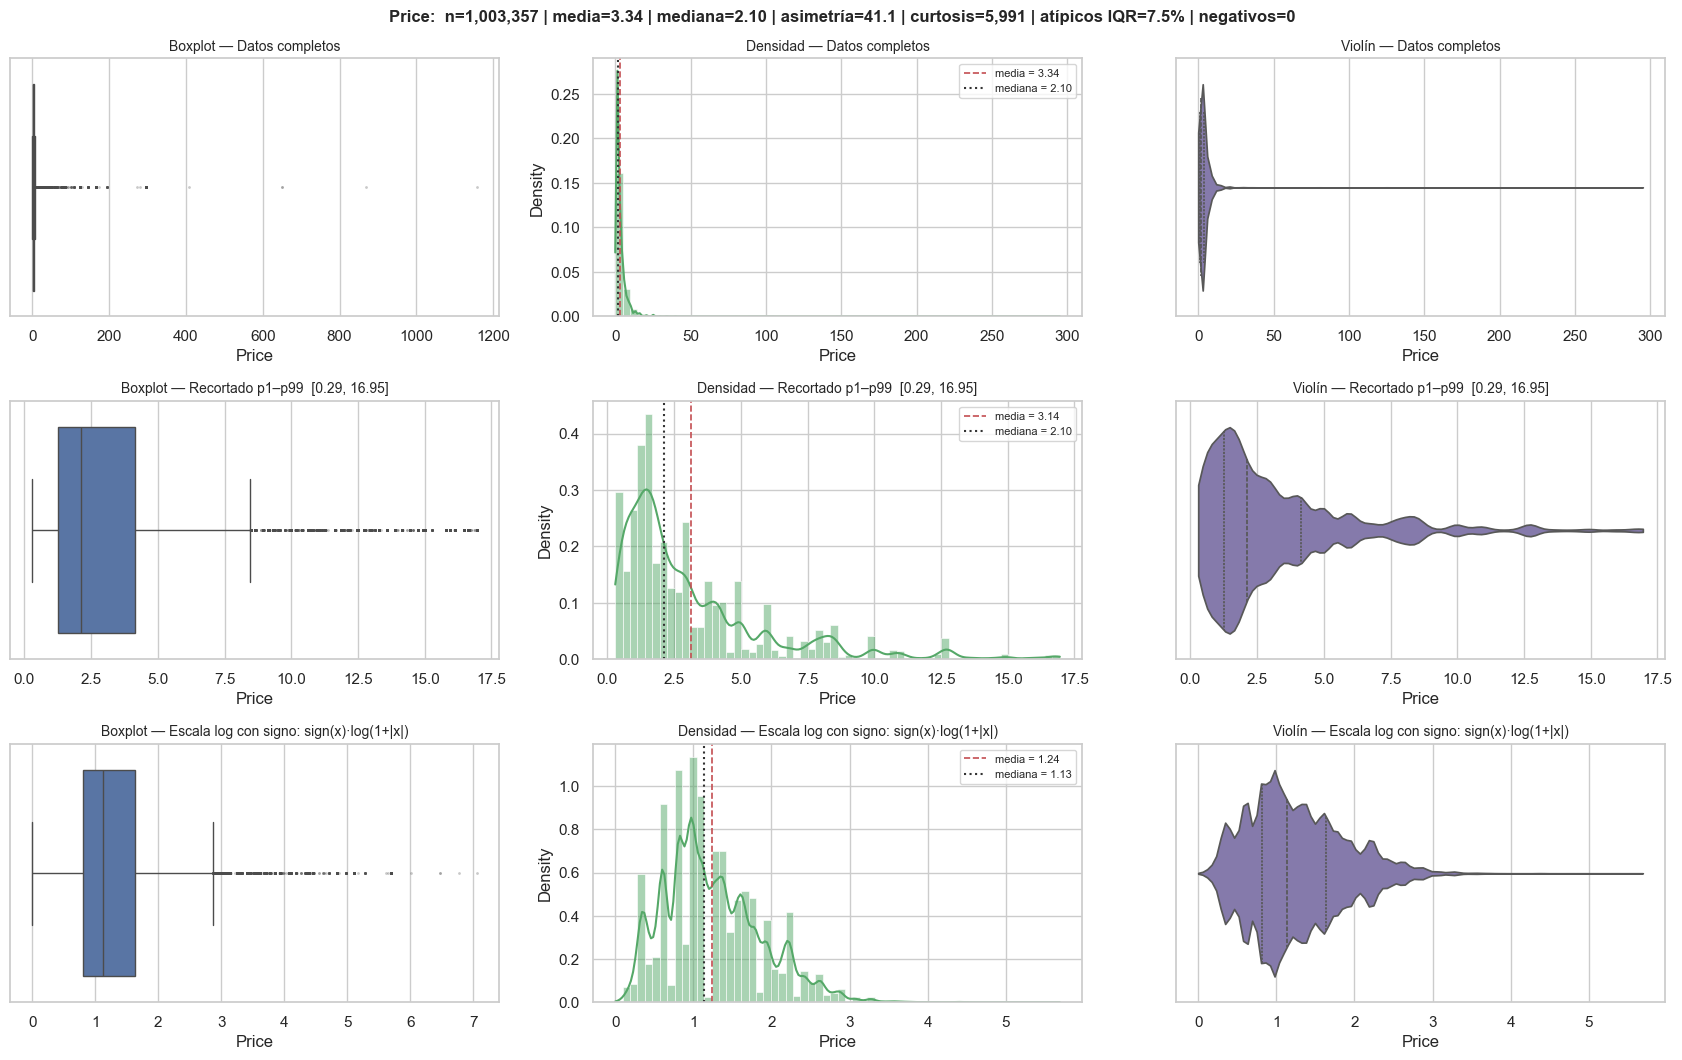

,n,media,mediana,desv_est,min,q1,q3,max,asimetria,curtosis,n_negativos,n_ceros,lim_inf_iqr,lim_sup_iqr,n_atipicos_iqr,pct_atipicos_iqr
Quantity,"1,003,357.0000",11.1506,4.0000,128.7379,1.0000,1.0000,12.0000,"80,995.0000",453.2112,"267,329.2090",0.0000,0.0000,-15.5000,28.5000,"53,019.0000",5.2842
Price,"1,003,357.0000",3.3401,2.1000,4.7549,0.0010,1.2500,4.1300,"1,157.1500",41.0914,"5,991.4679",0.0000,0.0000,-3.0700,8.4500,"75,064.0000",7.4813



5. VARIABLES CATEGÓRICAS: ['Country']


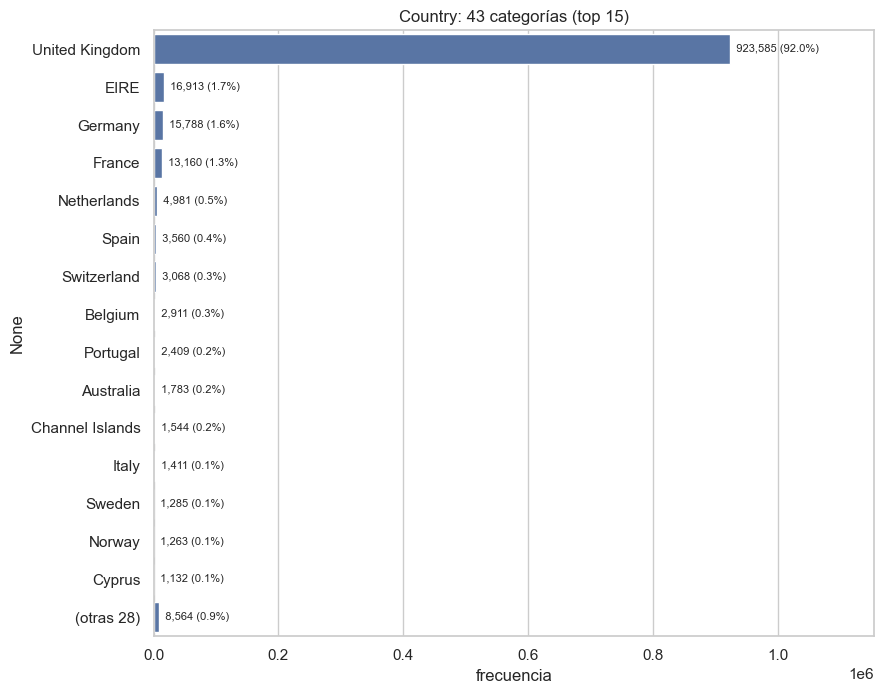


6. VARIABLES DE FECHA: ['InvoiceDate']


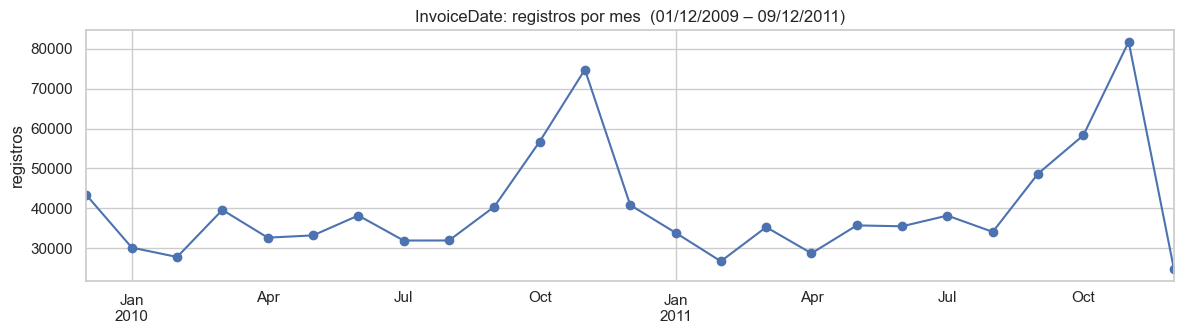

In [34]:
res_ventas = perfilar(ventas, ids=["Customer ID"])

**Interpretación del perfilado de ventas (comparado con el original, sección 3):**

| | Original | Ventas |
|---|---:|---:|
| Filas | 1,067,371 | 1,003,357 |
| Duplicados exactos | 12,133 | **0** |
| `Customer ID` faltante | 22.77% | 22.60% |
| `Description` faltante | 0.41% | **0%** |
| `Quantity` negativas | 22,950 | **0** |
| `Price` ≤ 0 | 6,207 | **0** |
| `Price` máximo | £38,970 | £1,157.15 |
| Atípicos IQR en `Quantity` / `Price` | 10.9% / 6.4% | 5.3% / 7.5% |

- **Tipos:** las mismas variables, ya sin `Sheet`. `Customer ID` ahora es `Int64`. Quedan 39,516 facturas, 4,726 productos y 5,852 clientes (los 170 códigos que solo diferían en mayúsculas/minúsculas se unificaron en 6.10).
- **Faltantes:** solo queda `Customer ID` (226,761 filas, 22.6%). Las descripciones vacías iban todas en filas con precio 0 o en ajustes.
- **`Quantity`:** va de 1 a 80,995, con mediana 4 y media 11.2. Los valores más frecuentes son 1, 2, 12, 6, 4 y 3. En la densidad se ven picos
  en 12, 24 y 48, que son tamaños de paquete mayorista. **Ojo:** los dos máximos (80,995 y 74,215) son compras cuya cancelación quedó
  en el conjunto `cancelaciones`. Por eso siguen inflando la asimetría (453) y la curtosis. Si se calculan ventas netas, hay que cruzarlas
  con sus cancelaciones.
- **`Price`:** va de £0.001 (`PADS`) a £1,157.15, con mediana £2.10 y media £3.34. Sin los cargos que no son productos, la desviación
  estándar baja de 123.6 a 4.75. El 7.5% de las filas son atípicas (> £8.45), casi todas productos caros reales.
- **`Country`:** Reino Unido 92.0%, Irlanda (EIRE) 1.7%, Alemania 1.6% y Francia 1.3%. No se modificó.
- **`InvoiceDate`:** la misma estacionalidad, ahora sin el doble conteo de diciembre de 2010. Las ventas crecen de septiembre a noviembre
  y noviembre es el pico (74,771 líneas en 2010 y 81,727 en 2011).

### 7.1 Revisiones finales de `ventas`

**¿Quedan `StockCode` con varias descripciones?** Se cuentan sobre `ventas` (y sobre `dfl` para comparar). En la tabla, cada
descripción va con su número de filas entre paréntesis, de la más frecuente a la menos frecuente.

In [35]:
n_desc_ventas = ventas.groupby("StockCode")["Description"].nunique()
multi = n_desc_ventas[n_desc_ventas > 1].index
print(f"StockCodes con más de una descripción -> dfl: {(dfl.groupby('StockCode')['Description'].nunique() > 1).sum():,} | "
      f"ventas: {len(multi):,} de {len(n_desc_ventas):,}")
print("Códigos según su número de descripciones:", n_desc_ventas.value_counts().sort_index().to_dict())

v_multi = ventas[ventas["StockCode"].isin(multi)]
print(f"Filas de ventas con alguno de estos códigos: {len(v_multi):,} ({len(v_multi) / len(ventas):.1%})")

# Códigos cuyas descripciones solo cambian en comas, barras, puntos o espacios
clave = v_multi["Description"].str.replace(r"[^A-Z0-9]", "", regex=True)
solo_puntuacion = (v_multi.assign(clave=clave).groupby("StockCode")["clave"].nunique() == 1).sum()
print(f"De ellos, solo difieren en puntuación o espacios: {solo_puntuacion:,}")

# El mismo código escrito con la letra final en mayúscula y en minúscula (por ejemplo 84997B y 84997b)
codigos = pd.Series(n_desc_ventas.index)
por_mayus = codigos.groupby(codigos.str.upper()).size()
print(f"StockCodes que solo difieren en mayúsculas/minúsculas: {(por_mayus > 1).sum():,} pares "
      f"(ej.: {', '.join(por_mayus[por_mayus > 1].index[:5])})")

conteo = v_multi.groupby(["StockCode", "Description"]).size().rename("filas").reset_index()
conteo = conteo.sort_values(["StockCode", "filas"], ascending=[True, False])
tabla_multi = (conteo.groupby("StockCode")
               .agg(n_descripciones=("Description", "size"),
                    filas=("filas", "sum"),
                    descripciones=("Description", lambda s: " | ".join(
                        f"{d} ({n:,})" for d, n in zip(s, conteo.loc[s.index, "filas"]))))
               .sort_values(["n_descripciones", "filas"], ascending=False))
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(tabla_multi)

StockCodes con más de una descripción -> dfl: 723 | ventas: 592 de 4,726
Códigos según su número de descripciones: {1: 4134, 2: 546, 3: 39, 4: 7}
Filas de ventas con alguno de estos códigos: 236,287 (23.5%)


De ellos, solo difieren en puntuación o espacios: 113
StockCodes que solo difieren en mayúsculas/minúsculas: 0 pares (ej.: )


,n_descripciones,filas,descripciones
StockCode,,,
22384,4,2137,"LUNCH BAG PINK POLKADOT (1,297) | LUNCH BAG PINK RETROSPOT (825) | LUNCHBAG PINK RETROSPOT (14) | LUNCH BAG PINK POLKADOTS (1)"
20685,4,1728,DOORMAT RED RETROSPOT (901) | DOOR MAT RED SPOT (412) | RED SPOTTY COIR DOORMAT (208) | DOORMAT RED SPOT (207)
23236,4,330,STORAGE TIN VINTAGE DOILY (192) | DOILEY STORAGE TIN (123) | DOILEY BISCUIT TIN (13) | STORAGE TIN VINTAGE DOILEY (2)
23196,4,304,VINTAGE LEAF MAGNETIC NOTEPAD (278) | RETRO LEAVES MAGNETIC NOTEPAD (21) | RETO LEAVES MAGNETIC SHOPPING LIST (3) | LEAVES MAGNETIC SHOPPING LIST (2)
22344,4,133,PARTY PIZZA DISH PINK POLKADOT (88) | PARTY PIZZA DISH PINK RETROSPOT (24) | PARTY PIZZA DISH PINK WHITE SPOT (19) | PARTY PIZZA DISH PINK+WHITE SPOT (2)
22345,4,130,PARTY PIZZA DISH BLUE POLKADOT (83) | PARTY PIZZA DISH BLUE RETROSPOT (28) | PARTY PIZZA DISH BLUE WHITE SPOT (17) | PARTY PIZZA DISH BLUE+WHITE SPOT (2)
22346,4,104,PARTY PIZZA DISH GREEN POLKADOT (69) | PARTY PIZZA DISH GREEN RETROSPOT (19) | PARTY PIZZA DISH GREEN WHITE SPOT (15) | PARTY PIZZA DISH GREEN+WHITE SPOT (1)
85099B,3,4067,"JUMBO BAG RED RETROSPOT (3,312) | JUMBO BAG RED WHITE SPOTTY (543) | RED RETROSPOT JUMBO BAG (212)"
22197,3,2366,"SMALL POPCORN HOLDER (1,428) | POPCORN HOLDER (825) | POPCORN HOLDER , SMALL (113)"


**Qué se observa:** sí quedan códigos con varias descripciones: **592** de 4,726 en `ventas` (723 en `dfl`). 546 tienen 2
descripciones, 39 tienen 3 y 7 tienen 4. Abarcan 236,287 filas (23.5% de `ventas`). Ya no son notas de inventario, sino el mismo
producto con nombres distintos:
- **Cambio de nombre en el catálogo:** `BLUE POLKADOT BOWL` / `BLUE SPOTTY BOWL`, `RED RETROSPOT PURSE` / `RED SPOTTY PURSE`.
- **Erratas y puntuación:** `FOOD/DRINK SPONGE STICKERS` / `SPUNGE`, `WRAP, CAROUSEL` / `WRAP CAROUSEL`. 113 códigos solo
  difieren en puntuación o espacios.
- **El código ya no varía en mayúsculas/minúsculas:** los 170 pares del tipo `84997B` / `84997b` se unificaron en 6.10, y la
  comprobación de arriba ya no encuentra ninguno.

Para análisis por producto conviene agrupar por código y, si hace falta un nombre, usar la descripción más frecuente o la más reciente.

**Países que quedaron en `ventas`:**

In [36]:
paises = ventas["Country"].value_counts().to_frame("filas")
paises["pct"] = 100 * paises["filas"] / len(ventas)
paises.index.name = "Country"
print(f"Países en ventas: {len(paises)} | en el original: {df['Country'].nunique()} | "
      f"¿son los mismos? {set(paises.index) == set(df['Country'].unique())}")
with pd.option_context("display.max_rows", None):
    display(paises)
print("En orden alfabético:")
print(", ".join(sorted(paises.index)))

Países en ventas: 43 | en el original: 43 | ¿son los mismos? True


,filas,pct
Country,,
United Kingdom,923585,92.0495
EIRE,16913,1.6856
Germany,15788,1.5735
France,13160,1.3116
Netherlands,4981,0.4964
Spain,3560,0.3548
Switzerland,3068,0.3058
Belgium,2911,0.2901
Portugal,2409,0.2401


En orden alfabético:
Australia, Austria, Bahrain, Belgium, Bermuda, Brazil, Canada, Channel Islands, Cyprus, Czech Republic, Denmark, EIRE, European Community, Finland, France, Germany, Greece, Hong Kong, Iceland, Israel, Italy, Japan, Korea, Lebanon, Lithuania, Malta, Netherlands, Nigeria, Norway, Poland, Portugal, RSA, Saudi Arabia, Singapore, Spain, Sweden, Switzerland, Thailand, USA, United Arab Emirates, United Kingdom, Unspecified, West Indies


**Qué se observa:** quedan los mismos **43** valores de `Country` que en el original; la limpieza no eliminó ningún país.
Reino Unido concentra el 92.0% de las filas y le siguen EIRE, Alemania y Francia. Hay países con muy pocas filas (Arabia Saudita 9,
República Checa 24, Nigeria 29). Dos valores no son países: `Unspecified` (748 filas) y `European Community` (57 filas).
`EIRE` es Irlanda y `RSA` es Sudáfrica.